# **Forecasting Corporate Credit Spreads Using Macroeconomic and Financial Indicators**

### **An Expanding-Window Regression Framework for One-Month-Ahead Forecasting**

## **Table of Contents**

1. **Project Overview**

2. **Import Libraries**

3. **Data Wrangling**
   - 3.1 Credit Spread Data
   - 3.2 CPI Public Release Data
   - 3.3 Unemployment Public Release Data
   - 3.4 Industrial Production Initial Release Data
   - 3.5 Federal Funds Rate Data
   - 3.6 GDP Public Release Data
   - 3.7 10-Year Minus 3-Month Treasury Yield Spread Data
   - 3.8 10-Year Treasury Yield Data
   - 3.9 VIX Data
   - 3.10 S&P 500 Data
   - 3.11 Russell 2000 Data
   - 3.12 Oil Price Data

4. **Feature Engineering**
   - 4.1 Year-over-Year Inflation
   - 4.2 Year-over-Year Industrial Production Growth
   - 4.3 Year-over-Year Real GDP Growth
   - 4.4 S&P 500 Monthly Returns
   - 4.5 Russell 2000 Monthly Returns
   - 4.6 WTI Crude Oil Monthly Returns
   - 4.7 Six-Month Rolling Credit Spread Volatility

5. **Dataset Integration and Temporal Alignment**
   - 5.1 Temporal Alignment
   - 5.2 Final Dataset Integration

6. **Exploratory Data Analysis (EDA)**
   - 6.1 Descriptive Analysis
   - 6.2 Time Series Analysis
   - 6.3 Correlation Analysis
   - 6.4 Lagged Relationships
   - 6.5 EDA Summary

7. **Lagged Feature Construction**
   - 7.1 Forecast Target
   - 7.2 Predictor Lags
   - 7.3 Feature-Target Correlations

8. **Modeling and Forecast Evaluation**
   - 8.1 Modeling Strategy and Time-Based Split
   - 8.2 Forecasting Benchmarks
     - 8.2.1 Naive Baseline Forecast
     - 8.2.2 Autoregressive AR(1) Benchmark
   - 8.3 Linear Regression Models
     - 8.3.1 Baseline OLS – Contemporaneous Economic/Market Predictors
     - 8.3.2 OLS with Credit Spread and Economic/Market Predictors
     - 8.3.3 OLS with Selected Current and Lagged Credit Spread and Macro-Financial Predictors

9. **Directional Forecast Evaluation**
   - 9.1 Directional Accuracy
   - 9.2 Pesaran–Timmermann Test

10. **Statistical Comparison of Forecast Accuracy: Diebold–Mariano Test**

11. **Conclusion**

12. **Limitations and Future Work**

## **1. Project Overview**

Credit spreads reflect the additional yield investors demand for holding corporate bonds rather than lower-risk U.S. Treasury securities. They tend to widen during periods of economic stress and heightened risk aversion and tighten when economic and financial conditions improve. As a result, credit spreads are closely monitored by fixed-income investors, credit analysts, portfolio managers, and policymakers as an indicator of corporate credit risk and broader financial conditions.

This project focuses on the **Moody’s Seasoned Baa Corporate Bond Yield Relative to the 10-Year Treasury Yield**, which measures the difference between yields on Baa-rated corporate bonds and 10-year U.S. Treasury securities. The objective is to **forecast this credit spread one month ahead** using publicly available macroeconomic and financial-market information.

Credit spreads are highly persistent, making simple persistence-based forecasts difficult to outperform. **The central research question is therefore whether one-month-ahead credit spread forecasts can be improved by incorporating additional information about macroeconomic conditions, interest rates, financial markets, and recent spread behavior and volatility**.

To investigate this question, the project compares multiple regression specifications using different combinations of macroeconomic and market predictors, lagged variables, and engineered features. These include information related to inflation, labor-market and economic activity, monetary policy and Treasury rates, equity-market conditions, market volatility, and commodity prices. Feature specifications are compared to assess whether these additional sources of information improve forecasting performance while maintaining model interpretability.

Out-of-sample performance is evaluated against simple time-series benchmarks, including naive persistence and an AR(1) model. Forecasts are assessed using error-based metrics such as **MAE** and **RMSE**, as well as **directional accuracy** to evaluate whether the models correctly predict spread widening or tightening. Statistical tests are also used to assess whether observed improvements over the benchmarks are meaningful rather than simply the result of sampling variation.

## **2. Import Libraries**

In [571]:
# Data Manipulation
import pandas as pd
import numpy as np
import requests
import yfinance as yf

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time Series Analysis
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Machine Learning
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# Statistical Testing
from scipy.stats import binomtest
from statsmodels.stats.contingency_tables import mcnemar

# Model Selection & Hyperparameter Tuning
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Model Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Utilities
import warnings
warnings.filterwarnings("ignore")


##  **3. Data Wrangling**

This section prepares the raw financial and macroeconomic data for analysis and modeling. The data wrangling process includes loading and inspecting the datasets, cleaning and transforming variables, aligning datasets with different frequencies, and merging them into a single time-series dataset.

This section prepares the raw financial and macroeconomic data for analysis and forecasting. The data-wrangling process includes loading and inspecting the individual datasets, cleaning and transforming raw fields, accounting for differences in data frequency and release timing, and preparing the series for alignment to a common monthly forecasting timeline.

The primary target variable is the **Moody’s Seasoned Baa Corporate Bond Yield Relative to the 10-Year Treasury Yield**, which measures the yield spread between Baa-rated corporate bonds and 10-year U.S. Treasury securities.

Predictor data include both **macroeconomic indicators and financial-market variables**. Macroeconomic variables include the **Consumer Price Index (CPI), unemployment rate, industrial production, real GDP, and the federal funds rate**.

Financial-market variables include the **10-year minus 3-month Treasury yield-curve slope, 10-year Treasury yield, VIX, S&P 500, Russell 2000, and West Texas Intermediate (WTI) crude oil prices**.
Together, these variables capture changes in interest rates, the shape of the yield curve, market volatility, broad and small-cap equity conditions, and commodity-market conditions that may be associated with changes in corporate credit spreads.For variables subject to publication delays or revisions, release timing is incorporated where appropriate to better reflect the information that would have been publicly available at each forecasting date.

At this stage, the datasets are retained largely in their original form after cleaning and initial preparation. In the subsequent **Feature Engineering** section, selected variables are transformed into forecasting features, including measures such as year-over-year growth rates, market returns, lagged variables, changes, and rolling measures. The resulting series are then aligned to a common monthly timeline for modeling.



In [572]:
!pip install pandas-datareader

In [573]:
from pandas_datareader import data as web
import datetime as dt

### **3.1 Credit Spread Data**

The target variable – Moody’s Seasoned Baa Corporate Bond Yield relative to the 10-Year Treasury yield (BAA10YM) is obtained directly from FRED. The spread represents the additional yield investors require to hold Baa-rated corporate bonds instead of U.S. Treasury securities, reflecting perceived corporate credit risk and broader market conditions.

In [397]:
# Load target variable: Moody's Baa Corporate Credit Spread

url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=BAA10YM"

credit_spread = pd.read_csv(url)

credit_spread.head()

,observation_date,BAA10YM
0,1953-04-01,0.82
1,1953-05-01,0.73
2,1953-06-01,0.75
3,1953-07-01,0.93
4,1953-08-01,0.90


In [398]:
# Target variable structure

credit_spread.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  881 non-null    object 
 1   BAA10YM           881 non-null    float64
dtypes: float64(1), object(1)
memory usage: 13.9+ KB


In [399]:
# Renaming the columns for better readability
# and converting to appropriate data types

credit_spread = credit_spread.rename(
    columns={
        "observation_date": "date",
        "BAA10YM": "credit_spread"
    }
)

credit_spread["date"] = pd.to_datetime(credit_spread["date"])

credit_spread.head()

,date,credit_spread
0,1953-04-01,0.82
1,1953-05-01,0.73
2,1953-06-01,0.75
3,1953-07-01,0.93
4,1953-08-01,0.90


In [400]:
credit_spread.shape

(881, 2)

In [401]:
credit_spread["date"].min(), credit_spread["date"].max()

(Timestamp('1953-04-01 00:00:00'), Timestamp('2026-08-01 00:00:00'))

In [402]:
# Checking for missing values
credit_spread.isnull().sum()

,0
date,0
credit_spread,0


**The Credit Spread dataset** contains no missing or duplicate observations, and both columns have appropriate data types. The dataset contains 881 monthly observations spanning from April 1953 to July 2026

### **3.2 CPI Public Release Data**

Initial-release CPI data are retrieved to ensure that the information used for foreacasting reflects what was publicly available at each point in time. CPI observations are published after the month they represent and may subsequently be revised. The FRED API parameter output_type = 4 returns only the initial release of each CPI observation, helping prevent look-ahead bias in the forecasting model.

In [403]:
from google.colab import userdata

fred_api_key = userdata.get("FRED_API_KEY")

In [404]:
# Retrieve initial-release CPI observations from the FRED API

# FRED endpoint used to retrieve historical observations for a specific series
url = "https://api.stlouisfed.org/fred/series/observations"

# Define the parameters of the API request
params = {
    "series_id": "CPIAUCSL",        # CPI for All Urban Consumers, seasonally adjusted
    "api_key": fred_api_key,        # FRED API key stored securely in Colab
    "file_type": "json",            # Return the API response in JSON format
    "realtime_start": "1990-01-01", # Retrieve real-time history beginning in 1990
    "output_type": 4                # Return initial-release observations only
}

# Send the request to FRED
response = requests.get(url, params=params)

# Check whether the API request was successful (HTTP status 200 = success)
print(response.status_code)

# Parse the JSON response into a Python dictionary
cpi_initial_data = response.json()

200


In [405]:
# Inspecting the structure of the API response
cpi_initial_data.keys()

dict_keys(['realtime_start', 'realtime_end', 'observation_start', 'observation_end', 'units', 'output_type', 'file_type', 'order_by', 'sort_order', 'count', 'offset', 'limit', 'observations'])

In [406]:
# Creating a DataFrame from the initial-release CPI observations

cpi_initial = pd.DataFrame(cpi_initial_data["observations"])

cpi_initial.head()

,realtime_start,realtime_end,date,value
0,1990-01-18,1991-02-19,1989-12-01,126.3
1,1990-02-21,1991-02-19,1990-01-01,127.7
2,1990-03-20,1991-02-19,1990-02-01,128.3
3,1990-04-17,1991-02-19,1990-03-01,128.9
4,1990-05-16,1991-02-19,1990-04-01,129.1


`date` represents the period the **CPI observation refers to**, `realtime_start` is **the date that reported value first became publicly available**, `realtime_end` marks the end of the period during which that particular vintage remained valid in ALFRED, and value is the CPI level reported for that observation period.

In [407]:
# Cleaning and renaming the columns for the point-in-time CPI data

cpi_initial = cpi_initial.rename(columns={
    "realtime_start": "release_date",
    "date": "cpi_period",
    "value": "cpi"
})

cpi_initial = cpi_initial[
    ["release_date", "cpi_period", "cpi"]
]

cpi_initial.head()

,release_date,cpi_period,cpi
0,1990-01-18,1989-12-01,126.3
1,1990-02-21,1990-01-01,127.7
2,1990-03-20,1990-02-01,128.3
3,1990-04-17,1990-03-01,128.9
4,1990-05-16,1990-04-01,129.1


In [408]:
cpi_initial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   release_date  440 non-null    object
 1   cpi_period    440 non-null    object
 2   cpi           440 non-null    object
dtypes: object(3)
memory usage: 10.4+ KB


In [409]:
# Converting dates to datetime and CPI values to numeric format

cpi_initial["release_date"] = pd.to_datetime(cpi_initial["release_date"])
cpi_initial["cpi_period"] = pd.to_datetime(cpi_initial["cpi_period"])
cpi_initial["cpi"] = pd.to_numeric(cpi_initial["cpi"], errors = "coerce")
cpi_initial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   release_date  440 non-null    datetime64[ns]
 1   cpi_period    440 non-null    datetime64[ns]
 2   cpi           439 non-null    float64       
dtypes: datetime64[ns](2), float64(1)
memory usage: 10.4 KB


In [410]:
# Checking the shape of the updated cpi_initial dataset
cpi_initial.shape

(440, 3)

In [411]:
# Checking for missing values

cpi_initial[cpi_initial["cpi"].isna()]

,release_date,cpi_period,cpi
430,2025-12-18,2025-10-01,NaN


In [412]:
cpi_initial["release_date"].min(), cpi_initial["release_date"].max()

(Timestamp('1990-01-18 00:00:00'), Timestamp('2026-08-12 00:00:00'))

**The CPI Initial Release dataset** contains 440 monthly observations. The first observation represents **December 1989 CPI, initially released on January 18, 1990**, and the most recent observation represents **July 2026 CPI**, which was r**eleased on August 12, 2026**. One CPI observation, **October 2025, is missing (NaN)** due to the government shutdown and will be addressed during subsequent preprocessing and alignment.

### **3.3 Unemployment Public Release Data**

The unemployment rate is reported monthly but becomes available only when the Employment Situation report is released. To avoid look-ahead bias, initial-release unemployment observations are retrieved from FRED/ALFRED. The initial release represents the information that would have been available to market participants at that point in time and is therefore used as the unemployment input for forecasting

In [413]:
# Retrieving initial-release unemployment observations from FRED

url = "https://api.stlouisfed.org/fred/series/observations"

params = {
    "series_id": "UNRATE",          # U.S. unemployment rate
    "api_key": fred_api_key,
    "file_type": "json",            # Return the API response in JSON format
    "realtime_start": "1990-01-01", # Beginning of the period used in the project
    "output_type": 4                # Initial-release observations only
}

# Sending the request to the FRED API
response = requests.get(url, params=params)

# Checking whether the request was successful (HTTP status 200 = success)
print(response.status_code)

# Parsing the JSON response into a Python dictionary
unemployment_initial_data = response.json()

200


In [414]:
# Looking at the structure of the API response
unemployment_initial_data.keys()

dict_keys(['realtime_start', 'realtime_end', 'observation_start', 'observation_end', 'units', 'output_type', 'file_type', 'order_by', 'sort_order', 'count', 'offset', 'limit', 'observations'])

In [415]:
# Inspecting the first unemployment observation returned by the API
unemployment_initial_data["observations"][0]

{'realtime_start': '1990-01-05',
 'realtime_end': '1993-01-07',
 'date': '1989-12-01',
 'value': '5.3'}

In [416]:
# Converting the initial-release unemployment observations to a DataFrame

unemployment_initial = pd.DataFrame(
    unemployment_initial_data["observations"]
)

# Keeping and renaming the relevant fields
unemployment_initial = unemployment_initial[
    ["realtime_start", "date", "value"]
].rename(columns={
    "realtime_start": "release_date",
    "date": "unemployment_period",
    "value": "unemployment_rate_initial"
})

# Inspecting the first 24 observations
unemployment_initial.head(13)

,release_date,unemployment_period,unemployment_rate_initial
0,1990-01-05,1989-12-01,5.3
1,1990-02-02,1990-01-01,5.3
2,1990-03-09,1990-02-01,5.3
3,1990-04-06,1990-03-01,5.2
4,1990-05-04,1990-04-01,5.4
5,1990-06-01,1990-05-01,5.3
6,1990-07-06,1990-06-01,5.2
7,1990-08-03,1990-07-01,5.5
8,1990-09-07,1990-08-01,5.6
9,1990-10-05,1990-09-01,5.7


In [417]:
unemployment_initial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 441 entries, 0 to 440
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   release_date               441 non-null    object
 1   unemployment_period        441 non-null    object
 2   unemployment_rate_initial  441 non-null    object
dtypes: object(3)
memory usage: 10.5+ KB


The unemployment rate is typically **released during the first several days of the month following the reference month.** The release dates are retained at this stage and will be addressed later during temporal alignment and integration of the datasets.

In [418]:
# Converting dates to datetime and unemployment values to numeric format

unemployment_initial["release_date"] = pd.to_datetime(
    unemployment_initial["release_date"]
)

unemployment_initial["unemployment_period"] = pd.to_datetime(
    unemployment_initial["unemployment_period"]
)

unemployment_initial["unemployment_rate_initial"] = pd.to_numeric(
    unemployment_initial["unemployment_rate_initial"],
    errors="coerce"
)

unemployment_initial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 441 entries, 0 to 440
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   release_date               441 non-null    datetime64[ns]
 1   unemployment_period        441 non-null    datetime64[ns]
 2   unemployment_rate_initial  440 non-null    float64       
dtypes: datetime64[ns](2), float64(1)
memory usage: 10.5 KB


In [419]:
# Check missing unemployment values
unemployment_initial[
    unemployment_initial["unemployment_rate_initial"].isna()
]

,release_date,unemployment_period,unemployment_rate_initial
430,2025-12-16,2025-10-01,NaN


In [420]:
# Checking for duplicate unemployment release dates
print(
    "Duplicate release dates:",
    unemployment_initial["release_date"].duplicated().sum()
)

# Checking duplicate unemployment periods
print(
    "Duplicate unemployment periods:",
    unemployment_initial["unemployment_period"].duplicated().sum()
)

Duplicate release dates: 1
Duplicate unemployment periods: 0


In [421]:
# Inspecting unemployment observations with duplicate release dates
unemployment_initial[
    unemployment_initial["release_date"].duplicated(keep=False)
].sort_values("release_date")

,release_date,unemployment_period,unemployment_rate_initial
430,2025-12-16,2025-10-01,NaN
431,2025-12-16,2025-11-01,4.6


The October 2025 unemployment observation is missing due to the 2025 government shutdown, which disrupted the regular data release schedule. This missing value and the resulting release-date alignment issue will be addressed in the data cleaning and integration steps.

### **3.4 Industrial Production Initial Release Data**

**The Industrial Production Index (INDPRO)** measures real output in the U.S. manufacturing, mining, and utilities sectors and serves as an indicator of economic activity. Initial-release observations are retrieved from FRED/ALFRED to avoid look-ahead bias and are later converted to year-over-year growth and aligned to the month in which they became publicly available.

In [422]:
import requests
import pandas as pd

series_id = "INDPRO"

url = "https://api.stlouisfed.org/fred/series/observations"

params = {
"series_id": series_id,
"api_key": fred_api_key,
"file_type": "json",
"observation_start": "1990-01-01",
"observation_end": "2026-07-31",
"realtime_start": "1990-01-01",
"realtime_end": "2026-08-29",
"output_type": 4
}

response = requests.get(url, params=params)
data = response.json()["observations"]

indpro = pd.DataFrame(data)

indpro.head()

,realtime_start,realtime_end,date,value
0,1990-02-16,1990-03-15,1990-01-01,140.9
1,1990-03-16,1990-04-16,1990-02-01,141.8
2,1990-04-17,1990-05-14,1990-03-01,108.8
3,1990-05-15,1990-06-14,1990-04-01,108.7
4,1990-06-15,1990-07-16,1990-05-01,109.7


In [423]:
# Converting the initial-release Industrial Production observations to a DataFrame
# Renaming the columns
indpro_initial = pd.DataFrame(data)

# Keeping and renaming the relevant fields
indpro_initial = indpro_initial[
    ["realtime_start", "date", "value"]
].rename(columns={
    "realtime_start": "release_date",
    "date": "indpro_period",
    "value": "indpro"
})

indpro_initial.head(13)

,release_date,indpro_period,indpro
0,1990-02-16,1990-01-01,140.9
1,1990-03-16,1990-02-01,141.8
2,1990-04-17,1990-03-01,108.8
3,1990-05-15,1990-04-01,108.7
4,1990-06-15,1990-05-01,109.7
5,1990-07-17,1990-06-01,109.8
6,1990-08-15,1990-07-01,109.9
7,1990-09-14,1990-08-01,109.8
8,1990-10-17,1990-09-01,110.7
9,1990-11-13,1990-10-01,109.6


In [424]:
# Converting dates to datetime and Industrial Production values to numeric format

indpro_initial["release_date"] = pd.to_datetime(
indpro_initial["release_date"]
)

indpro_initial["indpro_period"] = pd.to_datetime(
indpro_initial["indpro_period"]
)

indpro_initial["indpro"] = pd.to_numeric(
indpro_initial["indpro"],
errors="coerce"
)

indpro_initial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439 entries, 0 to 438
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   release_date   439 non-null    datetime64[ns]
 1   indpro_period  439 non-null    datetime64[ns]
 2   indpro         439 non-null    float64       
dtypes: datetime64[ns](2), float64(1)
memory usage: 10.4 KB


In [425]:
# Checking for duplicate Industrial Production periods

indpro_initial["indpro_period"].duplicated().sum()

np.int64(0)

In [426]:
# Load revised Industrial Production data from FRED
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=INDPRO"

indpro = pd.read_csv(url)

# Rename columns
indpro.rename(
    columns={
        "observation_date": "indpro_period",
        "INDPRO": "indpro"
        },
    inplace=True
)

# Convert date to datetime
indpro["indpro_period"] = pd.to_datetime(indpro["indpro_period"])

indpro = indpro[
    (indpro["indpro_period"] >= "1990-01-01") &
    (indpro["indpro_period"] <= "2026-08-31")
].copy()

indpro.head()

,indpro_period,indpro
852,1990-01-01,61.7290
853,1990-02-01,62.2896
854,1990-03-01,62.5999
855,1990-04-01,62.4359
856,1990-05-01,62.6258


Historical initial-release industrial production data were initially considered to preserve point-in-time information. However, inconsistencies were identified in some historical observations, likely reflecting changes in historical benchmarks and revisions to the series. To maintain a consistent measure of industrial production across the sample, the revised INDPRO series is therefore used, while historical release dates are used to approximate when the information became publicly available. Industrial production for each reference month is typically released around the middle of the following month, so each observation is aligned to the end of the following month (`MonthEnd(2)`). For example, January 1990 industrial production is assigned to February 28, 1990, reflecting its availability during February.

In [427]:
# Creating the model date as the end of the following month
indpro["date"] = (
    indpro["indpro_period"] + pd.offsets.MonthEnd(2)
)

indpro.head()

,indpro_period,indpro,date
852,1990-01-01,61.7290,1990-02-28
853,1990-02-01,62.2896,1990-03-31
854,1990-03-01,62.5999,1990-04-30
855,1990-04-01,62.4359,1990-05-31
856,1990-05-01,62.6258,1990-06-30


In the Feature Engineering section, industrial production will be converted to a growth rate for use in the modeling dataset.

### **3.5 Federal Funds Rate Data**

The Federal Funds Rate represents the overnight interest rate at which banks lend reserve balances to one another and is a key indicator of U.S. monetary policy. The monthly effective federal funds rate is obtained directly from FRED and is used to capture changes in the overall interest-rate environment.

In [428]:
# Loading monetary policy variable: Federal Funds Rate

fed_funds_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=FEDFUNDS"

fed_funds = pd.read_csv(fed_funds_url)

fed_funds.head()

,observation_date,FEDFUNDS
0,1954-07-01,0.80
1,1954-08-01,1.22
2,1954-09-01,1.07
3,1954-10-01,0.85
4,1954-11-01,0.83


In [429]:
# Inspecting Federal Funds Rate dataset

fed_funds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 866 entries, 0 to 865
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  866 non-null    object 
 1   FEDFUNDS          866 non-null    float64
dtypes: float64(1), object(1)
memory usage: 13.7+ KB


In [430]:
fed_funds.shape

(866, 2)

In [431]:
fed_funds["observation_date"].min(), fed_funds["observation_date"].max()

('1954-07-01', '2026-08-01')

In [432]:
# Renaming columns for consistency
fed_funds = fed_funds.rename(
    columns={
        "observation_date": "date",
        "FEDFUNDS": "fed_funds_rate"
    }
)

In [433]:
# Converting date column to datetime
fed_funds["date"] = pd.to_datetime( fed_funds["date"])

In [434]:
# Check for missing values
fed_funds[fed_funds["fed_funds_rate"].isna()]

,date,fed_funds_rate


In [435]:
# Check for duplicate observations
fed_funds.duplicated().sum()

np.int64(0)

**The Federal Funds Rate dataset** contains 866 **monthly** observations spanning from July 1954 to August 2026. The columns were renamed for consistency, and the date column was converted to datetime format. The dataset contains no missing values or duplicate observations.

### **3.6 GDP Public Release Data**

Real GDP is included as a measure of overall U.S. economic activity. Historical GDP release dates were initially retrieved to construct a release-aware series; however, changes in historical GDP definitions and benchmark revisions created inconsistencies between older initial-release values and the current GDP series. Therefore, the revised real GDP series is used for consistency, while historical release dates are used to preserve realistic information timing. Each quarterly GDP observation is aligned to the month in which the corresponding GDP estimate first became publicly available, preventing the model from using GDP information before its release. The GDP series will later be converted to year-over-year growth for use as a predictor.

In [436]:
# Loading revised Real GDP data
gdp_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=GDPC1"

gdp = pd.read_csv(gdp_url)

gdp.head()

,observation_date,GDPC1
0,1947-01-01,2182.681
1,1947-04-01,2176.892
2,1947-07-01,2172.432
3,1947-10-01,2206.452
4,1948-01-01,2239.682


In [437]:
# Cleaning revised Real GDP data
gdp = gdp.rename(columns={
    "observation_date": "gdp_period",
    "GDPC1": "gdp"
})

gdp["gdp_period"] = pd.to_datetime(gdp["gdp_period"])
gdp["gdp"] = pd.to_numeric(gdp["gdp"], errors="coerce")

gdp.head()

,gdp_period,gdp
0,1947-01-01,2182.681
1,1947-04-01,2176.892
2,1947-07-01,2172.432
3,1947-10-01,2206.452
4,1948-01-01,2239.682


In [438]:
# Loading historical GDP release dates from ALFRED
series_id = "GDPC1"

url = "https://api.stlouisfed.org/fred/series/observations"

params = {
"series_id": series_id,
"api_key": fred_api_key,
"file_type": "json",
"observation_start": "1990-01-01",
"observation_end": "2026-07-31",
"realtime_start": "1990-01-01",
"realtime_end": "2026-09-01",
"output_type": 4
}

response = requests.get(url, params=params)
data = response.json()["observations"]

gdp_releases = pd.DataFrame(data)

gdp_releases = gdp_releases[
["realtime_start", "date"]
].rename(columns={
"realtime_start": "release_date",
"date": "gdp_period"
})

gdp_releases["release_date"] = pd.to_datetime(
gdp_releases["release_date"]
)

gdp_releases["gdp_period"] = pd.to_datetime(
gdp_releases["gdp_period"]
)

gdp_releases.head()

,release_date,gdp_period
0,1992-01-29,1991-10-01
1,1992-04-28,1992-01-01
2,1992-07-30,1992-04-01
3,1992-10-27,1992-07-01
4,1993-01-28,1992-10-01


Historical release dates show that the first GDP estimate for each quarter generally becomes available near the end of the month following the quarter’s completion. For example, the GDP observation dated October 1, 1991, representing 1991 Q4, was first released on January 29, 1992. Because historical initial-release GDP values could not be used consistently due to benchmark revisions, the revised real GDP series is retained and its dates are shifted by four month-ends to approximate the historical information timing. Thus, the October 1, 1991 observation is assigned to January 31, 1992, ensuring that the GDP value does not enter the modeling dataset before the corresponding GDP estimate would have been publicly available.

In [439]:
# Adding "date" column with the end month date of the release month
gdp["date"] = (
    gdp["gdp_period"] + pd.offsets.MonthEnd(4)
)

gdp.head()

,gdp_period,gdp,date
0,1947-01-01,2182.681,1947-04-30
1,1947-04-01,2176.892,1947-07-31
2,1947-07-01,2172.432,1947-10-31
3,1947-10-01,2206.452,1948-01-31
4,1948-01-01,2239.682,1948-04-30


In [440]:
# Checking for missing values
gdp.isna().sum()

,0
gdp_period,0
gdp,0
date,0


In [441]:
# Checking for duplicate rows
gdp.duplicated().sum()

np.int64(0)

The GDP dataset contains no missing values or duplicate observations. In later sections, real GDP will be converted to year-over-year growth and transformed to monthly frequency for alignment with the remaining variables in the modeling dataset.

### **3.7 10-Year Minus 3 Month Treasury Yield Spread Data**

**The 10-year minus 3-month Treasury spread** is a measure of the slope of the U.S. Treasury yield curve. The 3-month yield closely reflects current short-term monetary conditions, while the 10-year yield reflects longer-term expectations for economic growth, inflation, and interest rates. The 10Y–3M spread was selected over the commonly used 10Y–2Y spread because it provides a clearer contrast between current short-term conditions and longer-term expectations and has historically been used as a leading indicator of U.S. recessions. A negative spread represents an inverted yield curve and may signal expectations of weaker future economic conditions, which can also be relevant for corporate credit spreads.

In [442]:
# Loading the 10-Year minus 3-Month Treasury spread from FRED

url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=T10Y3M"

yield_curve = pd.read_csv(url)

yield_curve.head(12)

,observation_date,T10Y3M
0,1982-01-04,2.32
1,1982-01-05,2.24
2,1982-01-06,2.43
3,1982-01-07,2.46
4,1982-01-08,2.50
5,1982-01-11,2.32
6,1982-01-12,2.10
7,1982-01-13,2.13
8,1982-01-14,1.53
9,1982-01-15,2.08


In [443]:
yield_curve.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11655 entries, 0 to 11654
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  11655 non-null  object 
 1   T10Y3M            11172 non-null  float64
dtypes: float64(1), object(1)
memory usage: 182.2+ KB


In [444]:
# Renaming columns for consistency
yield_curve = yield_curve.rename(
    columns={
        "observation_date": "date",
        "T10Y3M": "yield_curve_10y3m"
    }
)

# Convert date column to datetime
yield_curve["date"] = pd.to_datetime(yield_curve["date"])

In [445]:
# Checking missing observations
yield_curve[yield_curve["yield_curve_10y3m"].isna()].head(20)

,date,yield_curve_10y3m
29,1982-02-12,NaN
30,1982-02-15,NaN
69,1982-04-09,NaN
105,1982-05-31,NaN
130,1982-07-05,NaN
175,1982-09-06,NaN
200,1982-10-11,NaN
216,1982-11-02,NaN
223,1982-11-11,NaN
233,1982-11-25,NaN


In [446]:
# Total number of missing values
yield_curve["yield_curve_10y3m"].isna().sum()

np.int64(483)

In [447]:
# Missing yield-curve observations by year
yield_curve["year"] = yield_curve["date"].dt.year

yield_curve.groupby("year")["yield_curve_10y3m"].apply(
    lambda x: x.isna().sum()
)

,yield_curve_10y3m
year,
1982,11
1983,10
1984,12
1985,13
1986,11
1987,11
1988,11
1989,10
1990,11


The missing daily observations occur consistently throughout the series and largely correspond to U.S. holidays and other non-trading days. Since the yield curve will be aggregated to monthly frequency, missing daily observations are left unchanged and the monthly averages will be calculated from the available daily values

### **3.8 10-Year Treasury Yield Data**

**The 10-Year U.S. Treasury yield** is included to capture the level of long-term interest rates, complementing the 10Y–3M yield curve, which primarily captures the slope of the yield curve. Daily observations are retrieved from FRED to ensure that only information available at the time is used. The daily series will later be aligned to monthly frequency using the last available observation of each month.

In [448]:
# Load daily 10-Year Treasury Rate from FRED
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS10"

treasury_10y = pd.read_csv(url)

treasury_10y.rename(
    columns={
        "observation_date": "date",
        "DGS10": "treasury_10y"
        },
    inplace=True
)

treasury_10y["date"] = pd.to_datetime(treasury_10y["date"])

treasury_10y.head()

,date,treasury_10y
0,1962-01-02,4.06
1,1962-01-03,4.03
2,1962-01-04,3.99
3,1962-01-05,4.02
4,1962-01-08,4.03


### **3.9 VIX Data**

**The VIX (CBOE Volatility Index)** measures the market’s expectations of near-term volatility based on S&P 500 index options and is commonly used as an indicator of market uncertainty and investor risk sentiment. The daily VIX observations are later aggregated to monthly frequency using the monthly average to capture the overall level of market stress during each month.

In [449]:
# Loading market variable: VIX Volatility Index

vix_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=VIXCLS"

vix = pd.read_csv(vix_url)

vix.head()

,observation_date,VIXCLS
0,1990-01-02,17.24
1,1990-01-03,18.19
2,1990-01-04,19.22
3,1990-01-05,20.11
4,1990-01-08,20.26


In [450]:
vix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  9568 non-null   object 
 1   VIXCLS            9266 non-null   float64
dtypes: float64(1), object(1)
memory usage: 149.6+ KB


In [451]:
vix.shape

(9568, 2)

In [452]:
# Renaming columns for consistency
vix = vix.rename(
    columns={
        "observation_date": "date",
        "VIXCLS": "vix"
    }
)

# Converting date column to datetime
vix["date"] = pd.to_datetime(vix["date"])

In [453]:
# Identifying missing VIX observations
vix[vix["vix"].isna()]

,date,vix
34,1990-02-19,NaN
73,1990-04-13,NaN
104,1990-05-28,NaN
131,1990-07-04,NaN
174,1990-09-03,NaN
232,1990-11-22,NaN
255,1990-12-25,NaN
260,1991-01-01,NaN
294,1991-02-18,NaN
303,1991-03-01,NaN


In [454]:
vix.duplicated().sum()

np.int64(0)

**The VIX dataset** contains **daily** observations beginning in January 1990. The columns were renamed for consistency, and the date column was converted to datetime format. The dataset contains 302 missing observations, which are retained at this stage and will be addressed when the daily series is aggregated to monthly frequency.

### **3.10 S&P 500 Data**

**The S&P 500** is a broad measure of U.S. equity market performance and is used as an indicator of market conditions and investor risk sentiment. Daily closing prices are retrieved from Yahoo Finance and later converted to monthly returns using month-end closing prices. Equity market declines may signal deteriorating economic or financial conditions and can be associated with widening corporate credit spreads.

In [455]:
# Load market variable: S&P 500 Daily Prices

import yfinance as yf
sp500 = yf.download(
    "^GSPC",
    start="1990-01-01",
    end="2026-09-01",
    auto_adjust=True
)

sp500.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
1990-01-02,359.690002,359.690002,351.980011,353.399994,162070000
1990-01-03,358.760010,360.589996,357.890015,359.690002,192330000
1990-01-04,355.670013,358.760010,352.890015,358.760010,177000000
1990-01-05,352.200012,355.670013,351.350006,355.670013,158530000
1990-01-08,353.790009,354.239990,350.540009,352.200012,140110000


In [456]:
# Cleaning S&P 500 data
sp500 = sp500.reset_index()

sp500 = sp500.rename(columns={
    "Date": "date",
    "Close": "sp500_close"
})

sp500["date"] = pd.to_datetime(sp500["date"])

# Only daily close data is relevant for our dataset
sp500 = sp500[["date", "sp500_close"]]

In [457]:
sp500.head()

Price,date,sp500_close
Ticker,,^GSPC
0,1990-01-02,359.690002
1,1990-01-03,358.760010
2,1990-01-04,355.670013
3,1990-01-05,352.200012
4,1990-01-08,353.790009


In [458]:
# Flattening the MultiIndex columns
sp500.columns = sp500.columns.get_level_values(0)

# Removing the "Price" label above the columns
sp500.columns.name = None

# Another check
sp500.head()

,date,sp500_close
0,1990-01-02,359.690002
1,1990-01-03,358.760010
2,1990-01-04,355.670013
3,1990-01-05,352.200012
4,1990-01-08,353.790009


The S&P 500 dataset was cleaned and prepared for subsequent integration. Only the daily closing price and date are retained, as these are the variables required to construct S&P 500 returns. The daily data will later be converted to monthly frequency when the datasets are aligned and integrated into a single modeling dataset.

### **3.11 Russel 2000 Data**

**The Russell 2000 Index** tracks U.S. small-cap companies and provides an additional measure of equity market conditions. Smaller companies tend to be more sensitive to changes in interest rates, financing conditions, and economic stress due to their greater dependence on external financing and generally more limited financial resources. Russell 2000 performance is therefore included as a potential early indicator of changing corporate credit conditions. Daily prices are later converted to monthly returns using month-end closing prices.

In [459]:
# Downloading Russell 2000 daily data
russell = yf.download(
    "^RUT",
    start="1990-01-01",
    end="2026-09-01",
    auto_adjust=False
)

russell.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^RUT,^RUT,^RUT,^RUT,^RUT,^RUT
Date,,,,,,
1990-01-02,169.949997,169.949997,169.960007,168.220001,168.309998,162070000
1990-01-03,170.789993,170.789993,170.800003,169.960007,169.960007,192330000
1990-01-04,170.089996,170.089996,170.789993,169.580002,170.779999,177000000
1990-01-05,169.649994,169.649994,170.119995,169.440002,170.089996,158530000
1990-01-08,169.550003,169.550003,169.679993,169.050003,169.669998,140110000


In [460]:
# Cleaning Russell 2000 data
russell = russell.reset_index()

russell = russell.rename(columns={
    "Date": "date",
    "Close": "russell2000_close"
})

russell["date"] = pd.to_datetime(russell["date"])

# Only daily close data is relevant for our dataset
russell = russell[["date", "russell2000_close"]]

In [461]:
# Flattening the MultiIndex columns
russell.columns = russell.columns.get_level_values(0)

# Removing the "Price" label above the columns
russell.columns.name = None

# Another check
russell.head()

,date,russell2000_close
0,1990-01-02,169.949997
1,1990-01-03,170.789993
2,1990-01-04,170.089996
3,1990-01-05,169.649994
4,1990-01-08,169.550003


### **3.12 Oil Price Data**

WTI (West Texas Intermediate) crude oil prices are included as an additional market and macroeconomic indicator because changes in energy prices can affect inflation expectations, corporate costs, and broader economic conditions. Daily observations are retrieved from FRED and will later be transformed and aligned to monthly frequency during feature engineering.

In [462]:
# Load daily WTI Crude Oil prices from FRED
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DCOILWTICO"

oil_data = pd.read_csv(url)

# Rename columns
oil_data.rename(
    columns={
        "observation_date": "date",
        "DCOILWTICO": "wti_oil_price"
        },
    inplace=True
)

# Convert date to datetime
oil_data["date"] = pd.to_datetime(oil_data["date"])

oil_data.head()

,date,wti_oil_price
0,1986-01-02,25.56
1,1986-01-03,26.00
2,1986-01-06,26.53
3,1986-01-07,25.85
4,1986-01-08,25.87


In [463]:
print("Shape:", oil_data.shape)
print("Date range:", oil_data["date"].min(), "to", oil_data["date"].max())
print("Duplicate rows:", oil_data.duplicated().sum())
print("Duplicate dates:", oil_data["date"].duplicated().sum())

print("\nMissing values:")
print(oil_data.isna().sum())

oil_data.head()

Shape: (10609, 2)
Date range: 1986-01-02 00:00:00 to 2026-09-01 00:00:00
Duplicate rows: 0
Duplicate dates: 0

Missing values:
date               0
wti_oil_price    373
dtype: int64


,date,wti_oil_price
0,1986-01-02,25.56
1,1986-01-03,26.00
2,1986-01-06,26.53
3,1986-01-07,25.85
4,1986-01-08,25.87


The WTI dataset contains no duplicate observations. A small number of daily price observations are missing, largely reflecting days when no price was reported. These values are left unchanged because the series will later be transformed into monthly returns and aligned to month-end during feature engineering.

## **4. Feature Engineering**

This section transforms the cleaned raw variables into economically meaningful features for forecasting. CPI is converted into year-over-year inflation,and S&P 500 closing prices into monthly returns. The unemployment rate and the remaining financial variables are retained in their existing form.  
Financial variables available at a daily frequency, including the VIX and 10-year minus 3-month Treasury yield-curve slope, are subsequently aggregated to monthly frequency during the temporal alignment process.

### **4.1 Year-over-Year Inflation**

Year-over-year inflation measures the percentage change in the **Consumer Price Index (CPI)** relative to the same month one year earlier. It is calculated as:

$$
\text{Inflation YoY}_t =
\left(\frac{CPI_t}{CPI_{t-12}} - 1\right) \times 100
$$

This transformation converts the CPI index level into an annual inflation rate that can be used as a macroeconomic predictor in the forecasting model.

In [464]:
# Calculating year-over-year inflation from initial-release CPI values
# Missing CPI observations remain missing rather than being filled automatically

cpi_initial["inflation_yoy_initial"] = (
    cpi_initial["cpi"].pct_change(12, fill_method=None) * 100
)

In [465]:
cpi_initial[
    ["release_date", "cpi_period", "cpi", "inflation_yoy_initial"]
].head(15)

,release_date,cpi_period,cpi,inflation_yoy_initial
0,1990-01-18,1989-12-01,126.3,NaN
1,1990-02-21,1990-01-01,127.7,NaN
2,1990-03-20,1990-02-01,128.3,NaN
3,1990-04-17,1990-03-01,128.9,NaN
4,1990-05-16,1990-04-01,129.1,NaN
5,1990-06-15,1990-05-01,129.3,NaN
6,1990-07-18,1990-06-01,130.0,NaN
7,1990-08-16,1990-07-01,130.5,NaN
8,1990-09-18,1990-08-01,131.5,NaN
9,1990-10-18,1990-09-01,132.5,NaN


In [466]:
cpi_initial[
    cpi_initial["inflation_yoy_initial"].isna()
]

,release_date,cpi_period,cpi,inflation_yoy_initial
0,1990-01-18,1989-12-01,126.3,NaN
1,1990-02-21,1990-01-01,127.7,NaN
2,1990-03-20,1990-02-01,128.3,NaN
3,1990-04-17,1990-03-01,128.9,NaN
4,1990-05-16,1990-04-01,129.1,NaN
5,1990-06-15,1990-05-01,129.3,NaN
6,1990-07-18,1990-06-01,130.0,NaN
7,1990-08-16,1990-07-01,130.5,NaN
8,1990-09-18,1990-08-01,131.5,NaN
9,1990-10-18,1990-09-01,132.5,NaN


In [467]:
# Checking duplicate CPI release dates
print("Duplicate release dates:",
      cpi_initial["release_date"].duplicated().sum())
# Checking duplicate CPI periods
print("Duplicate CPI periods:",
      cpi_initial["cpi_period"].duplicated().sum())

Duplicate release dates: 1
Duplicate CPI periods: 0


In [468]:
# Inspecting CPI observations with duplicate release dates
cpi_initial[
    cpi_initial["release_date"].duplicated(keep=False)
].sort_values("release_date")

,release_date,cpi_period,cpi,inflation_yoy_initial
430,2025-12-18,2025-10-01,NaN,NaN
431,2025-12-18,2025-11-01,325.031,2.714566


The first 12 missing year-over-year inflation values are expected because each observation requires a CPI value from the same month one year earlier. The additional missing value corresponds to October 2025, when the CPI observation was unavailable due to the government shutdown. The December 2025 release date therefore appears twice, reflecting the unavailable October observation and the subsequently released November observation. This duplicate release date will be addressed during temporal alignment to ensure that only the latest available information is carried forward in the monthly modeling dataset.

### **4.2 Year-over-Year Industrial Production Growth**

Year-over-year industrial production growth measures the percentage change in the Industrial Production Index relative to the same month one year earlier. It is calculated as:

$$
\text{Industrial Production Growth}_t =
\left(\frac{INDPRO_t}{INDPRO_{t-12}} - 1\right) \times 100
$$

where $INDPRO_t$ represents the Industrial Production Index for the current month and $INDPRO_{t-12}$ represents the index for the same month one year earlier.

This transformation converts the Industrial Production Index level into an annual growth rate that captures changes in U.S. industrial activity and can be used as a macroeconomic predictor in the forecasting model.

In [469]:
# Calculating year-over-year Industrial Production growth
indpro["indpro_growth"] = (
    indpro["indpro"].pct_change(12) * 100
)

indpro.head(30)

,indpro_period,indpro,date,indpro_growth
852,1990-01-01,61.7290,1990-02-28,NaN
853,1990-02-01,62.2896,1990-03-31,NaN
854,1990-03-01,62.5999,1990-04-30,NaN
855,1990-04-01,62.4359,1990-05-31,NaN
856,1990-05-01,62.6258,1990-06-30,NaN
857,1990-06-01,62.8382,1990-07-31,NaN
858,1990-07-01,62.7284,1990-08-31,NaN
859,1990-08-01,62.9475,1990-09-30,NaN
860,1990-09-01,62.9523,1990-10-31,NaN
861,1990-10-01,62.5845,1990-11-30,NaN


In [470]:
# Checking for unusually large Industrial Production growth changes
indpro.loc[
    indpro["indpro_growth"].abs() > 15,
    ["date", "indpro_period", "indpro", "indpro_growth"]
]

,date,indpro_period,indpro,indpro_growth
1084,2009-06-30,2009-05-01,85.0665,-15.160361
1085,2009-07-31,2009-06-01,84.7459,-15.282480
1215,2020-05-31,2020-04-01,84.5619,-17.318282
1216,2020-06-30,2020-05-01,85.9604,-16.047738
1227,2021-05-31,2021-04-01,98.5587,16.552135
1228,2021-06-30,2021-05-01,99.4333,15.673380


In [471]:
# Inspect duplicate dates
indpro[
    indpro["date"].duplicated(keep=False)
].sort_values("date")

,indpro_period,indpro,date,indpro_growth


### **4.3 Year-over-Year Real GDP Growth**

Year-over-year real GDP growth measures the percentage change in real GDP relative to the same quarter one year earlier. It is calculated using the same general approach as year-over-year inflation and industrial production growth, but because GDP is reported quarterly, each observation is compared with the corresponding quarter four quarters earlier.

$$
\text{GDP Growth}_t =
\left(\frac{GDP_t}{GDP_{t-4}} - 1\right) \times 100
$$

where $GDP_t$ represents real GDP for the current quarter and $GDP_{t-4}$ represents real GDP for the same quarter one year earlier.

Because GDP is released quarterly while the modeling dataset uses monthly observations, each GDP growth observation is assigned to its release-aware month-end date and then forward-filled across subsequent months until a new GDP observation becomes available. This ensures that each month uses the most recently available GDP information rather than introducing information before its release.

In [472]:
# Calculating year-over-year Real GDP growth
gdp["gdp_growth"] = (
    gdp["gdp"].pct_change(4, fill_method=None) * 100
)

gdp.head()

,gdp_period,gdp,date,gdp_growth
0,1947-01-01,2182.681,1947-04-30,NaN
1,1947-04-01,2176.892,1947-07-31,NaN
2,1947-07-01,2172.432,1947-10-31,NaN
3,1947-10-01,2206.452,1948-01-31,NaN
4,1948-01-01,2239.682,1948-04-30,2.611513


In [473]:
# Keeping the aligned GDP date and growth
gdp_monthly = gdp[["date", "gdp_growth"]].copy()

# Expanding quarterly GDP observations to monthly frequency
gdp_monthly = (
    gdp_monthly
    .set_index("date")
    .resample("ME")
    .ffill()
    .reset_index()
)

gdp_monthly.head(20)

,date,gdp_growth
0,1947-04-30,NaN
1,1947-05-31,NaN
2,1947-06-30,NaN
3,1947-07-31,NaN
4,1947-08-31,NaN
5,1947-09-30,NaN
6,1947-10-31,NaN
7,1947-11-30,NaN
8,1947-12-31,NaN
9,1948-01-31,NaN


In [474]:
# Checking for missing values
gdp_monthly[gdp_monthly["gdp_growth"].isna()]

,date,gdp_growth
0,1947-04-30,NaN
1,1947-05-31,NaN
2,1947-06-30,NaN
3,1947-07-31,NaN
4,1947-08-31,NaN
5,1947-09-30,NaN
6,1947-10-31,NaN
7,1947-11-30,NaN
8,1947-12-31,NaN
9,1948-01-31,NaN


The first twelve values are missing, which is expected.


### **4.4 S&P 500 Monthly Returns**

S&P 500 monthly returns measure the percentage change in the index from one month-end to the next. Daily closing prices are first converted to monthly observations using the last available trading-day closing price of each month.

Monthly returns are calculated as:

$$
\text{S\&P 500 Return}_t =
\left(\frac{P_t}{P_{t-1}} - 1\right) \times 100
$$

where $P_t$ represents the S&P 500 closing price at the end of the current month and $P_{t-1}$ represents the closing price at the end of the previous month.

This transformation converts the S&P 500 price level into a monthly market-return measure that can be used as a financial predictor in the forecasting model.

In [475]:
# Converting daily S&P 500 closing prices to month-end observations
sp500_monthly = (
    sp500
    .set_index("date")
    .resample("ME")
    .last()
    .reset_index()
)

sp500_monthly.head()

,date,sp500_close
0,1990-01-31,329.079987
1,1990-02-28,331.890015
2,1990-03-31,339.940002
3,1990-04-30,330.799988
4,1990-05-31,361.230011


In [476]:
# Calculating S&P 500 monthly returns
sp500_monthly["sp500_return"] = (
    sp500_monthly["sp500_close"].pct_change(fill_method=None) * 100
)

sp500_monthly.head()

,date,sp500_close,sp500_return
0,1990-01-31,329.079987,NaN
1,1990-02-28,331.890015,0.853904
2,1990-03-31,339.940002,2.425499
3,1990-04-30,330.799988,-2.688714
4,1990-05-31,361.230011,9.198919


In [477]:
# Checking missing S&P 500 monthly returns
sp500_monthly[
    sp500_monthly["sp500_return"].isna()
]

,date,sp500_close,sp500_return
0,1990-01-31,329.079987,NaN


The first monthly return is missing as expected because there is no prior month-end closing price available for calculating the percentage change. No additional missing monthly returns are present.

### **4.5 Russel 2000 Monthly Returns**

Russell 2000 monthly returns are calculated using the same methodology as the S&P 500 monthly returns described above. Daily closing prices are converted to month-end observations using the last available trading-day closing price of each month, and the percentage change between consecutive month-end prices is calculated to obtain monthly returns.

In [478]:
# Converting daily Russell 2000 closing prices to month-end observations
russell_monthly = (
    russell
    .set_index("date")
    .resample("ME")
    .last()
    .reset_index()
)

russell_monthly.head()

,date,russell2000_close
0,1990-01-31,153.270004
1,1990-02-28,157.720001
2,1990-03-31,163.630005
3,1990-04-30,158.089996
4,1990-05-31,168.910004


In [479]:
# Calculating Russell 2000 monthly returns
russell_monthly["russell2000_return"] = (
    russell_monthly["russell2000_close"].pct_change(fill_method=None) * 100
)

russell_monthly.head()

,date,russell2000_close,russell2000_return
0,1990-01-31,153.270004,NaN
1,1990-02-28,157.720001,2.903371
2,1990-03-31,163.630005,3.747149
3,1990-04-30,158.089996,-3.385692
4,1990-05-31,168.910004,6.844207


In [480]:
# Checking missing Russell 2000 monthly returns
russell_monthly[
    russell_monthly["russell2000_return"].isna()
]

,date,russell2000_close,russell2000_return
0,1990-01-31,153.270004,NaN


The first monthly return is missing as expected because there is no prior month-end closing price available for calculating the percentage change.

### **4.6 WTI Crude Oil Monthly Returns**

WTI crude oil monthly returns measure the percentage change in oil prices from one month-end to the next. Daily WTI prices are first converted to monthly observations using the last available price of each month.

Monthly returns are then calculated using the same methodology as the S&P 500 and Russell 2000 monthly returns described above. This transformation captures changes in energy prices rather than their absolute price level and provides a measure of oil-price movements that may affect inflation expectations, corporate costs, and broader economic conditions.

In [481]:
# Converting daily WTI prices to month-end observations
oil_monthly = (
    oil_data
    .set_index("date")
    .resample("ME")     # group all monthly observations
    .last()             # take the last observation of the month
    .reset_index()
)

In [482]:
# Calculating monthly WTI crude oil returns
oil_monthly["wti_monthly_return"] = (
    oil_monthly["wti_oil_price"]
    .pct_change(fill_method=None) * 100
)
oil_monthly.head()

,date,wti_oil_price,wti_monthly_return
0,1986-01-31,18.95,NaN
1,1986-02-28,13.23,-30.184697
2,1986-03-31,10.25,-22.524565
3,1986-04-30,13.38,30.536585
4,1986-05-31,14.30,6.875934


In [483]:
# Checking for missing values
oil_monthly[
    oil_monthly["wti_monthly_return"].isna()
]

,date,wti_oil_price,wti_monthly_return
0,1986-01-31,18.95,NaN


### **4.7 Six-Month Rolling Credit Spread Volatility**

A six-month rolling standard deviation of the credit spread is created as an additional predictor for the forecasting models. For each month, the measure calculates the standard deviation of credit spreads over the current and previous five months.

Because credit spreads tend to be persistent, their current level already contains substantial information about future spreads. The rolling standard deviation provides additional information about the recent stability of credit conditions by capturing how much spreads have fluctuated over the preceding six months. Higher values indicate greater recent credit-spread volatility, while lower values indicate more stable credit conditions.

This feature will be retained as an additional predictor for later modeling.

In [484]:
# Calculating 6-month rolling credit spread volatility
credit_spread["credit_spread_6m_volatility"] = (
    credit_spread["credit_spread"]
    .rolling(6)
    .std()
)

credit_spread.head(10)

,date,credit_spread,credit_spread_6m_volatility
0,1953-04-01,0.82,NaN
1,1953-05-01,0.73,NaN
2,1953-06-01,0.75,NaN
3,1953-07-01,0.93,NaN
4,1953-08-01,0.90,NaN
5,1953-09-01,1.01,0.109118
6,1953-10-01,1.16,0.161823
7,1953-11-01,1.07,0.143248
8,1953-12-01,1.15,0.109484
9,1954-01-01,1.23,0.119108


## **5. Dataset Integration and Temporal Alignment**

To establish a consistent monthly forecasting timeline, all observations are aligned to month-end dates. This convention is particularly appropriate for the credit-spread target, which is constructed from monthly-average yields and therefore reflects information accumulated throughout the month. Macroeconomic variables are aligned according to their public release timing, while higher-frequency financial variables are aggregated to monthly frequency. Using month-end as the common reference date ensures that each monthly observation represents information available by the corresponding forecasting date, helping maintain temporal consistency and reduce the risk of look-ahead bias.

### **5.1 Temporal Alignment**

In [485]:
# Aligning CPI releases to month-end
cpi_aligned = cpi_initial[
    ["release_date", "cpi_period", "inflation_yoy_initial"]
].copy()

cpi_aligned["date"] = (
    cpi_aligned["release_date"] + pd.offsets.MonthEnd(0)
)

cpi_aligned.head(15)

,release_date,cpi_period,inflation_yoy_initial,date
0,1990-01-18,1989-12-01,NaN,1990-01-31
1,1990-02-21,1990-01-01,NaN,1990-02-28
2,1990-03-20,1990-02-01,NaN,1990-03-31
3,1990-04-17,1990-03-01,NaN,1990-04-30
4,1990-05-16,1990-04-01,NaN,1990-05-31
5,1990-06-15,1990-05-01,NaN,1990-06-30
6,1990-07-18,1990-06-01,NaN,1990-07-31
7,1990-08-16,1990-07-01,NaN,1990-08-31
8,1990-09-18,1990-08-01,NaN,1990-09-30
9,1990-10-18,1990-09-01,NaN,1990-10-31


In [486]:
# Inspecting CPI alignment around the 2025 government shutdown
cpi_aligned[
    (cpi_aligned["date"] >= "2025-09-30") &
    (cpi_aligned["date"] <= "2026-01-31")
]

,release_date,cpi_period,inflation_yoy_initial,date
428,2025-09-11,2025-08-01,2.942497,2025-09-30
429,2025-10-24,2025-09-01,3.076718,2025-10-31
430,2025-12-18,2025-10-01,NaN,2025-12-31
431,2025-12-18,2025-11-01,2.714566,2025-12-31
432,2026-01-13,2025-12-01,2.626816,2026-01-31


In [487]:
# Removing duplicate month-end date
cpi_aligned = cpi_aligned.drop_duplicates(subset="date", keep="last")

In [488]:
cpi_aligned[
    (cpi_aligned["date"] >= "2025-09-30") &
    (cpi_aligned["date"] <= "2026-01-31")
]

,release_date,cpi_period,inflation_yoy_initial,date
428,2025-09-11,2025-08-01,2.942497,2025-09-30
429,2025-10-24,2025-09-01,3.076718,2025-10-31
431,2025-12-18,2025-11-01,2.714566,2025-12-31
432,2026-01-13,2025-12-01,2.626816,2026-01-31


In [489]:
# Adding the missing November 2025 month-end information set
nov_2025 = pd.DataFrame({
    "release_date": [pd.NaT],
    "cpi_period": [pd.NaT],
    "inflation_yoy_initial": [3.076718],
    "date": [pd.Timestamp("2025-11-30")]
})

cpi_aligned = pd.concat([cpi_aligned, nov_2025], ignore_index=True)

cpi_aligned = cpi_aligned.sort_values("date").reset_index(drop=True)

In [490]:
cpi_aligned[
    (cpi_aligned["date"] >= "2025-09-30") &
    (cpi_aligned["date"] <= "2026-01-31")
]

,release_date,cpi_period,inflation_yoy_initial,date
427,2025-09-11,2025-08-01,2.942497,2025-09-30
428,2025-10-24,2025-09-01,3.076718,2025-10-31
429,NaT,NaT,3.076718,2025-11-30
430,2025-12-18,2025-11-01,2.714566,2025-12-31
431,2026-01-13,2025-12-01,2.626816,2026-01-31


In [491]:
# Keep only the monthly forecasting date and inflation feature
cpi_aligned = cpi_aligned[
    ["date", "inflation_yoy_initial"]
].copy()

cpi_aligned.head()

,date,inflation_yoy_initial
0,1990-01-31,NaN
1,1990-02-28,NaN
2,1990-03-31,NaN
3,1990-04-30,NaN
4,1990-05-31,NaN


In [492]:
# Aggregating daily VIX observations to monthly averages
# Assigning each monthly observation to the corresponding month-end date

vix_monthly = (
    vix
    .set_index("date")
    .resample("ME")["vix"]
    .mean()
    .reset_index()
)

vix_monthly.head()

,date,vix
0,1990-01-31,23.347273
1,1990-02-28,23.262632
2,1990-03-31,20.062273
3,1990-04-30,21.403500
4,1990-05-31,18.097727


In [493]:
# Aligning unemployment releases to month-end
unemployment_aligned = unemployment_initial[
    ["release_date", "unemployment_period", "unemployment_rate_initial"]
].copy()

unemployment_aligned["date"] = (
    unemployment_aligned["release_date"] + pd.offsets.MonthEnd(0)
)

unemployment_aligned.head()

,release_date,unemployment_period,unemployment_rate_initial,date
0,1990-01-05,1989-12-01,5.3,1990-01-31
1,1990-02-02,1990-01-01,5.3,1990-02-28
2,1990-03-09,1990-02-01,5.3,1990-03-31
3,1990-04-06,1990-03-01,5.2,1990-04-30
4,1990-05-04,1990-04-01,5.4,1990-05-31


In [494]:
# Inspecting unemployment alignment around the 2025 government shutdown
unemployment_aligned[
    (unemployment_aligned["date"] >= "2025-09-30") &
    (unemployment_aligned["date"] <= "2026-01-31")
]

,release_date,unemployment_period,unemployment_rate_initial,date
428,2025-09-05,2025-08-01,4.3,2025-09-30
429,2025-11-20,2025-09-01,4.4,2025-11-30
430,2025-12-16,2025-10-01,NaN,2025-12-31
431,2025-12-16,2025-11-01,4.6,2025-12-31
432,2026-01-09,2025-12-01,4.4,2026-01-31


In [495]:
# Remove duplicate month-end date, keeping the valid latest release
unemployment_aligned = unemployment_aligned.drop_duplicates(
    subset="date",
    keep="last"
)

# Add the missing October 2025 month-end
oct_2025 = pd.DataFrame({
    "date": [pd.Timestamp("2025-10-31")],
    "unemployment_rate_initial": [np.nan]
})

unemployment_aligned = pd.concat(
    [unemployment_aligned, oct_2025],
    ignore_index=True
)

# Sort by date
unemployment_aligned = unemployment_aligned.sort_values("date").reset_index(drop=True)

# Carry forward the latest unemployment rate available at each month-end
unemployment_aligned["unemployment_rate_initial"] = (
    unemployment_aligned["unemployment_rate_initial"].ffill()
)

In [496]:
unemployment_aligned[
    (unemployment_aligned["date"] >= "2025-09-30") &
    (unemployment_aligned["date"] <= "2026-01-31")
]

,release_date,unemployment_period,unemployment_rate_initial,date
428,2025-09-05,2025-08-01,4.3,2025-09-30
429,NaT,NaT,4.3,2025-10-31
430,2025-11-20,2025-09-01,4.4,2025-11-30
431,2025-12-16,2025-11-01,4.6,2025-12-31
432,2026-01-09,2025-12-01,4.4,2026-01-31


In [497]:
# Converting daily 10Y–3M yield curve observations to month-end values
# Using the last available observation in each month

yield_curve_monthly = (
    yield_curve
    .set_index("date")
    .resample("ME")["yield_curve_10y3m"]
    .last()
    .reset_index()
)

yield_curve_monthly.head()

,date,yield_curve_10y3m
0,1982-01-31,1.06
1,1982-02-28,1.03
2,1982-03-31,0.19
3,1982-04-30,0.72
4,1982-05-31,1.74


The 10Y–3M Treasury yield spread is converted to monthly frequency using the last available observation of each month, so the feature reflects the prevailing shape of the yield curve at the month-end forecast date.

In [498]:
# Aligning daily 10-Year Treasury yield to month-end
treasury_10y_monthly = (
    treasury_10y
    .dropna(subset=["treasury_10y"])
    .set_index("date")
    .resample("ME")
    .last()
    .reset_index()
)
treasury_10y_monthly.head()

,date,treasury_10y
0,1962-01-31,4.10
1,1962-02-28,4.00
2,1962-03-31,3.86
3,1962-04-30,3.86
4,1962-05-31,3.90


The 10-Year Treasury yield is reported at a daily frequency. To align the series with the monthly modeling dataset, the last available daily observation of each month is used to represent the month-end interest-rate environment. This approach preserves the most recent market information available at the forecasting date.

In [499]:
# Assigning monthly credit spread and Federal Funds Rate observations
# to their corresponding month-end dates

credit_spread["date"] = (
    credit_spread["date"] + pd.offsets.MonthEnd(0)
)

fed_funds["date"] = (
    fed_funds["date"] + pd.offsets.MonthEnd(0)
)

In [500]:
print("Credit spread:", credit_spread.columns.tolist())
print("Fed funds:", fed_funds.columns.tolist())
print("Yield curve:", yield_curve.columns.tolist())
print("Treasury 10Y:", treasury_10y.columns.tolist())
print("Unemployment:", unemployment_initial.columns.tolist())
print("Inflation:", cpi_initial.columns.tolist())
print("VIX:", vix_monthly.columns.tolist())
print("S&P 500:", sp500_monthly.columns.tolist())
print("Russell 2000:", russell_monthly.columns.tolist())
print("Industrial production:", indpro.columns.tolist())
print("GDP:", gdp_monthly.columns.tolist())
print("Oil:", oil_monthly.columns.tolist())


Credit spread: ['date', 'credit_spread', 'credit_spread_6m_volatility']
Fed funds: ['date', 'fed_funds_rate']
Yield curve: ['date', 'yield_curve_10y3m', 'year']
Treasury 10Y: ['date', 'treasury_10y']
Unemployment: ['release_date', 'unemployment_period', 'unemployment_rate_initial']
Inflation: ['release_date', 'cpi_period', 'cpi', 'inflation_yoy_initial']
VIX: ['date', 'vix']
S&P 500: ['date', 'sp500_close', 'sp500_return']
Russell 2000: ['date', 'russell2000_close', 'russell2000_return']
Industrial production: ['indpro_period', 'indpro', 'date', 'indpro_growth']
GDP: ['date', 'gdp_growth']
Oil: ['date', 'wti_oil_price', 'wti_monthly_return']


In [501]:
# Confirming that each monthly dataset has one observation per date
datasets = {
    "credit_spread": credit_spread,
    "fed_funds": fed_funds,
    "yield_curve": yield_curve_monthly,
    "treasury_10y": treasury_10y_monthly,
    "vix": vix_monthly,
    "sp500": sp500_monthly,
    "russell_2000": russell_monthly,
    "inflation": cpi_aligned,
    "unemployment": unemployment_aligned,
    "industrial_production": indpro,
    "gdp": gdp_monthly,
    "oil": oil_monthly
}

for name, df in datasets.items():
    print(name, df["date"].duplicated().sum())

credit_spread 0
fed_funds 0
yield_curve 0
treasury_10y 0
vix 0
sp500 0
russell_2000 0
inflation 0
unemployment 0
industrial_production 0
gdp 0
oil 0


### **5.2 Final Dataset Integration**

In [502]:
# Using credit spread as the base dataset
final_data = credit_spread[
    ["date", "credit_spread", "credit_spread_6m_volatility"]
].copy()

# Merge predictors by date
final_data = final_data.merge(
    fed_funds[["date", "fed_funds_rate"]],
    on="date",
    how="left"
)

final_data = final_data.merge(
    yield_curve_monthly[["date", "yield_curve_10y3m"]],
    on="date",
    how="left"
)

final_data = final_data.merge(
    treasury_10y_monthly[["date", "treasury_10y"]],
    on="date",
    how="left"
)

final_data = final_data.merge(
    vix_monthly[["date", "vix"]],
    on="date",
    how="left"
)

final_data = final_data.merge(
    sp500_monthly[["date", "sp500_return"]],
    on="date",
    how="left"
)

final_data = final_data.merge(
    russell_monthly[["date", "russell2000_return"]],
    on="date",
    how="left"
)

final_data = final_data.merge(
    cpi_aligned[["date", "inflation_yoy_initial"]],
    on="date",
    how="left"
)

final_data = final_data.merge(
    unemployment_aligned[["date", "unemployment_rate_initial"]],
    on="date",
    how="left"
)

final_data = final_data.merge(
    indpro[["date", "indpro_growth"]],
    on="date",
    how="left"
)

final_data = final_data.merge(
    gdp_monthly[["date", "gdp_growth"]],
    on="date",
    how="left"
)

final_data = final_data.merge(
    oil_monthly[["date", "wti_monthly_return"]],
    on="date",
    how="left"
)

# Restrict to the common analysis period
final_data = final_data[
    final_data["date"] >= "1991-02-28"
].reset_index(drop=True)

final_data.head()

,date,credit_spread,credit_spread_6m_volatility,fed_funds_rate,yield_curve_10y3m,treasury_10y,vix,sp500_return,russell2000_return,inflation_yoy_initial,unemployment_rate_initial,indpro_growth,gdp_growth,wti_monthly_return
0,1991-02-28,2.22,0.233302,6.25,1.80,8.02,21.598421,6.728118,10.980094,5.559906,6.2,-0.961461,0.603063,-11.963470
1,1991-03-31,1.98,0.161204,6.12,2.13,8.05,17.744211,2.220283,6.881247,5.300078,6.5,-2.577958,0.603063,1.815353
2,1991-04-30,1.90,0.191590,5.91,2.34,8.02,17.372727,0.031980,-0.233901,4.732351,6.8,-3.618696,-0.950197,6.928171
3,1991-05-31,1.79,0.242899,5.78,2.35,8.06,16.932273,3.860497,4.530799,4.802479,6.6,-3.110550,-0.950197,0.809909
4,1991-06-30,1.68,0.258489,5.90,2.53,8.24,17.135000,-4.789263,-6.016595,4.949729,6.9,-2.494978,-0.950197,-2.835539


In [503]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 427 entries, 0 to 426
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   date                         427 non-null    datetime64[ns]
 1   credit_spread                427 non-null    float64       
 2   credit_spread_6m_volatility  427 non-null    float64       
 3   fed_funds_rate               427 non-null    float64       
 4   yield_curve_10y3m            427 non-null    float64       
 5   treasury_10y                 427 non-null    float64       
 6   vix                          427 non-null    float64       
 7   sp500_return                 427 non-null    float64       
 8   russell2000_return           427 non-null    float64       
 9   inflation_yoy_initial        426 non-null    float64       
 10  unemployment_rate_initial    427 non-null    float64       
 11  indpro_growth                427 non-null    

In [504]:
final_data[
    final_data["inflation_yoy_initial"].isna()
]

,date,credit_spread,credit_spread_6m_volatility,fed_funds_rate,yield_curve_10y3m,treasury_10y,vix,sp500_return,russell2000_return,inflation_yoy_initial,unemployment_rate_initial,indpro_growth,gdp_growth,wti_monthly_return
59,1996-01-31,1.82,0.04535,5.56,0.55,5.6,13.473636,3.261739,-0.186725,NaN,5.6,2.63969,2.199792,-9.109519


In [505]:
cpi_aligned[
    (cpi_aligned["date"] >= "1995-11-30") &
    (cpi_aligned["date"] <= "1996-03-31")
]

,date,inflation_yoy_initial
70,1995-11-30,2.809365
71,1995-12-31,2.535023
72,1996-02-29,2.722444
73,1996-03-31,2.649007


In [506]:
# Carrying forward the latest available inflation value to fill in the 01/31/1996
final_data["inflation_yoy_initial"] = (
    final_data["inflation_yoy_initial"].ffill()
)

In [507]:
final_data[
    (final_data["date"] >= "1995-12-31") &
    (final_data["date"] <= "1996-03-31")]

,date,credit_spread,credit_spread_6m_volatility,fed_funds_rate,yield_curve_10y3m,treasury_10y,vix,sp500_return,russell2000_return,inflation_yoy_initial,unemployment_rate_initial,indpro_growth,gdp_growth,wti_monthly_return
58,1995-12-31,1.78,0.030605,5.60,0.48,5.58,11.748500,1.744387,2.394846,2.535023,5.6,3.329850,2.673326,6.951286
59,1996-01-31,1.82,0.045350,5.56,0.55,5.60,13.473636,3.261739,-0.186725,2.535023,5.6,2.639690,2.199792,-9.109519
60,1996-02-29,1.82,0.046224,5.22,1.11,6.13,15.033000,0.693370,3.028089,2.722444,5.8,1.878822,2.199792,10.304054
61,1996-03-31,1.76,0.042740,5.31,1.21,6.34,17.762381,0.791657,1.797309,2.649007,5.5,3.486579,2.199792,9.392547


In [508]:
final_data.loc[
    final_data["gdp_growth"].isna(),
    ["date", "gdp_growth"]
]

,date,gdp_growth
426,2026-08-31,NaN


In [509]:
gdp_monthly.tail(10)

,date,gdp_growth
942,2025-10-31,2.335168
943,2025-11-30,2.335168
944,2025-12-31,2.335168
945,2026-01-31,1.989300
946,2026-02-28,1.989300
947,2026-03-31,1.989300
948,2026-04-30,2.684743
949,2026-05-31,2.684743
950,2026-06-30,2.684743
951,2026-07-31,2.097672


In [510]:
# Adding August 2026 using the latest available GDP growth
gdp_monthly.loc[len(gdp_monthly)] = [
    pd.Timestamp("2026-08-31"),
    gdp_monthly["gdp_growth"].iloc[-1]
]

gdp_monthly.tail()

,date,gdp_growth
948,2026-04-30,2.684743
949,2026-05-31,2.684743
950,2026-06-30,2.684743
951,2026-07-31,2.097672
952,2026-08-31,2.097672


In [511]:
final_data["gdp_growth"] = final_data["gdp_growth"].ffill()

In [512]:
final_data.isna().sum()

,0
date,0
credit_spread,0
credit_spread_6m_volatility,0
fed_funds_rate,0
yield_curve_10y3m,0
treasury_10y,0
vix,0
sp500_return,0
russell2000_return,0
inflation_yoy_initial,0


**Final Integrated Dataset**

The final dataset contains monthly observations with all variables aligned to a common month-end timeline. Macroeconomic indicators are aligned according to their historical information availability to reduce look-ahead bias, while daily financial-market variables are transformed to monthly frequency using either month-end observations, monthly averages, or monthly returns, depending on the variable.

The final dataset combines the credit spread with measures of monetary policy, interest rates, yield-curve conditions, market volatility, equity-market performance, inflation, unemployment, industrial production, GDP growth, and oil-price movements. A six-month rolling measure of credit-spread volatility is also included to capture changes in recent credit-market conditions.

Missing observations and duplicate dates were addressed during the data preparation and alignment process, resulting in a complete monthly dataset with no remaining missing values. The final dataset is ready for exploratory data analysis and subsequent forecasting models.

## **6. Exploratory Data Analysis (EDA)**

### **6.1 Descriptive Analysis**

In [513]:
final_data.drop(columns = "date").describe().T

,count,mean,std,min,25%,50%,75%,max
credit_spread,427.0,2.293653,0.714448,1.290000,1.755000,2.160000,2.690000,6.010000
credit_spread_6m_volatility,427.0,0.160627,0.161388,0.018708,0.077090,0.119108,0.192197,1.274720
fed_funds_rate,427.0,2.737283,2.176655,0.050000,0.215000,2.500000,5.040000,6.540000
yield_curve_10y3m,427.0,1.447588,1.286012,-1.880000,0.510000,1.490000,2.505000,3.820000
treasury_10y,427.0,4.106089,1.802746,0.550000,2.575000,4.110000,5.435000,8.240000
vix,427.0,19.323437,7.404225,10.125455,14.076792,17.565238,22.517310,62.668947
sp500_return,427.0,0.820148,4.224468,-16.942452,-1.718122,1.215565,3.486071,12.684404
russell2000_return,427.0,0.866421,5.563776,-21.899451,-2.818027,1.568939,4.238110,18.286879
inflation_yoy_initial,427.0,2.633184,1.540071,-2.149821,1.759747,2.560976,3.205754,8.984763
unemployment_rate_initial,427.0,5.648712,1.756214,3.400000,4.300000,5.300000,6.550000,14.700000


The descriptive statistics show substantial variation in credit spreads and macro-financial conditions over the sample period. Credit spreads average approximately 2.29 percentage points, with values ranging from 1.29 to 6.01, reflecting periods of significant spread widening. Credit-spread volatility also varies considerably, suggesting periods of heightened instability in credit markets. The VIX and equity-market returns exhibit substantial variation, with Russell 2000 returns showing greater volatility than S&P 500 returns. Macroeconomic indicators also span markedly different economic regimes: unemployment ranges from 3.4% to 14.7%, while inflation ranges from approximately −2.15% to 8.98%. Industrial production and GDP growth display sharp contractions and expansions across the sample. WTI monthly returns show particularly large fluctuations, ranging from approximately −54.25% to 84.97%, reflecting substantial variation in energy-market conditions. The 10-year–3-month yield curve ranges from −1.88 to 3.82 percentage points, capturing both inverted and positively sloped yield-curve environments. Overall, the dataset covers a broad range of economic and financial conditions relevant to credit-spread dynamics.

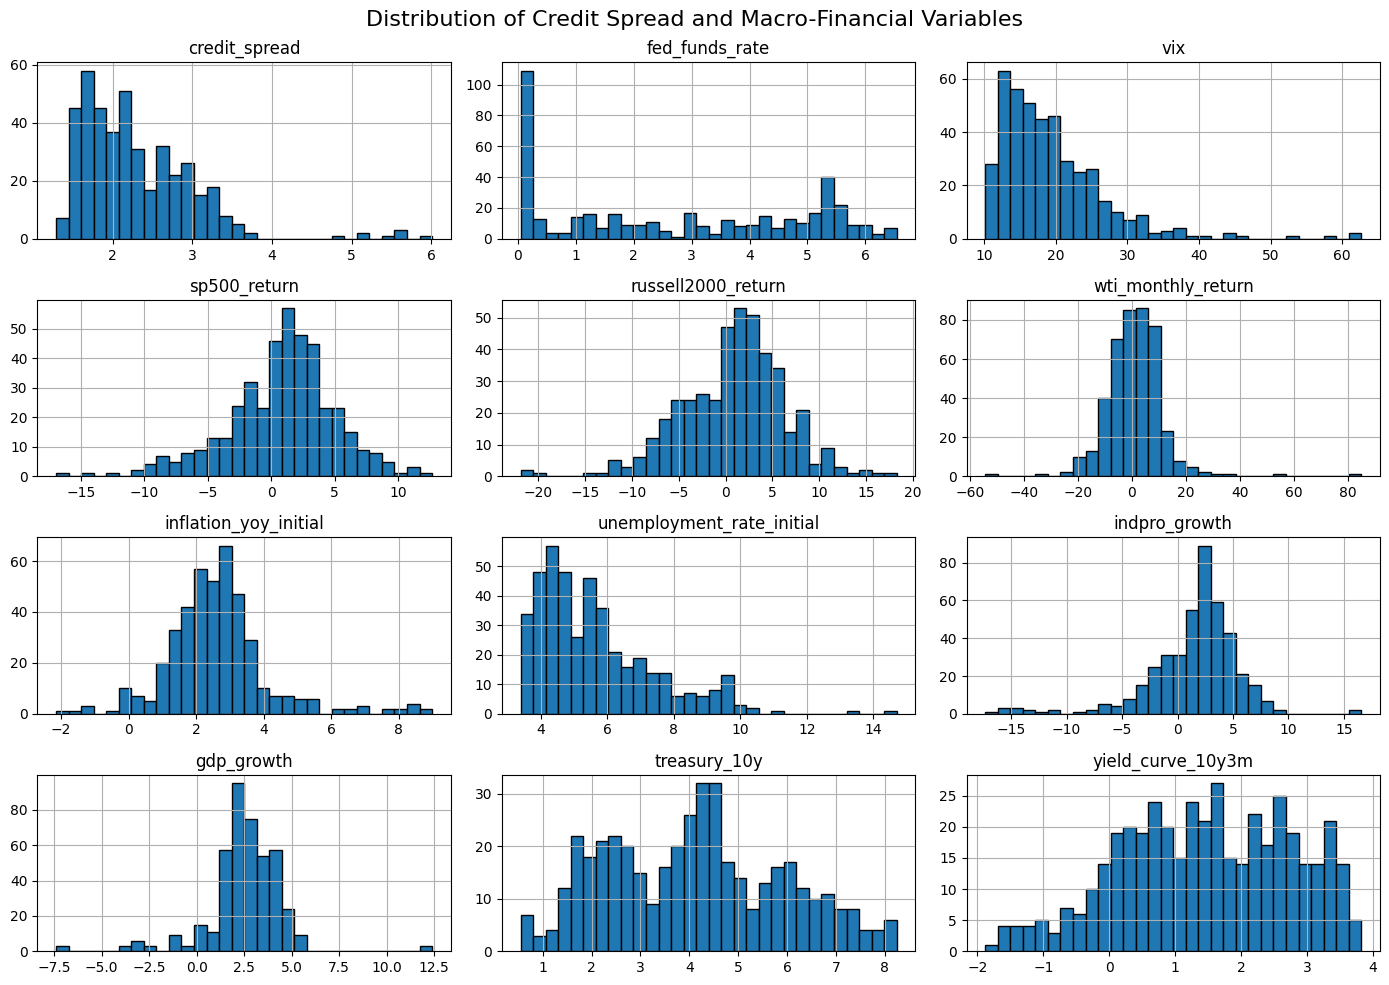

In [514]:
# Plot distributions of the credit spread and macro-financial variables

columns = [
    "credit_spread",
    "fed_funds_rate",
    "vix",
    "sp500_return",
    "russell2000_return",
    "wti_monthly_return",
    "inflation_yoy_initial",
    "unemployment_rate_initial",
    "indpro_growth",
    "gdp_growth",
    "treasury_10y",
    "yield_curve_10y3m",
]

final_data[columns].hist(
    bins=30,
    figsize=(14, 10),
    edgecolor="black"
)

plt.suptitle(
    "Distribution of Credit Spread and Macro-Financial Variables",
    fontsize=16
)

plt.tight_layout()
plt.show()

The histograms illustrate substantial differences in the distributions of the credit spread and macro-financial variables. Credit spreads are right-skewed, with most observations concentrated between approximately 1.5% and 3.0%, while a small number of observations exceed 5% during periods of significant market stress. The VIX and unemployment rate are also right-skewed, reflecting occasional periods of unusually high financial and economic stress. Inflation is largely concentrated around 2–3%, although the distribution includes both negative inflation and substantially higher inflation periods.

Equity-market returns are centered near small positive values, with the Russell 2000 exhibiting a wider distribution than the S&P 500, consistent with greater volatility in small-cap equities. WTI monthly returns display particularly pronounced tails, with most observations concentrated near zero but several exceptionally large positive and negative monthly movements. Industrial production and GDP growth are generally concentrated around positive growth rates but contain large negative observations associated with periods of economic contraction. The 10-year Treasury yield spans a wide range of interest-rate environments, while the 10-year–3-month yield curve includes both negative and positive values, capturing periods of yield-curve inversion as well as positively sloped conditions. Overall, the distributions demonstrate that the sample covers both typical economic conditions and periods of substantial macroeconomic and financial stress.

### **6.2 Time Series Analysis**

This section examines the behavior of credit spreads over time to identify underlying trends, periods of market stress, and changes in volatility. The analysis considers the historical credit spread series together with its 12-month rolling mean and rolling standard deviation, providing insight into both the evolution and stability of credit market conditions over the sample period.

#### **6.2.1 Credit Spread Over Time**

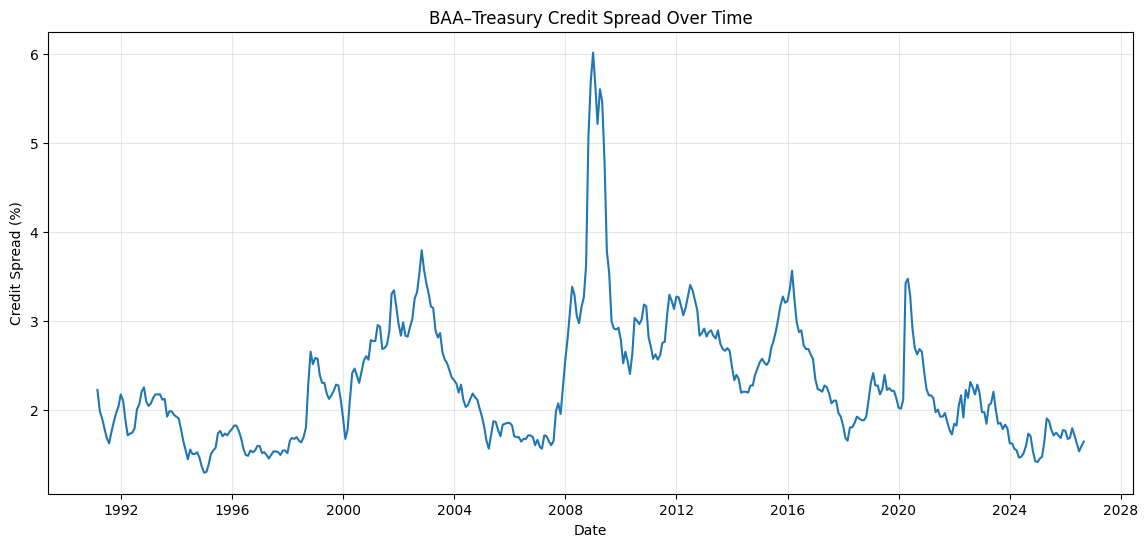

In [515]:
# Plotting the credit spread over time

plt.figure(figsize=(14, 6))

plt.plot(final_data["date"], final_data["credit_spread"])

plt.title("BAA–Treasury Credit Spread Over Time")
plt.xlabel("Date")
plt.ylabel("Credit Spread (%)")
plt.grid(True, alpha=0.3)

plt.show()

The credit spread exhibits distinct periods of widening associated with economic and financial stress. Elevated spreads during 2000–2003 coincide with the dot-com downturn, the 2001 recession, and broader corporate credit concerns, while the most pronounced widening occurs during the 2008–2009 Global Financial Crisis. Another notable increase appears during 2015–2016 amid commodity-market and global growth concerns, despite the absence of a U.S. recession. A sharp but relatively short-lived widening is also visible during the 2020 COVID-19 shock. Overall, the series shows that credit spreads tend to remain relatively contained during stable periods but can widen rapidly when economic uncertainty and perceived credit risk increase.

#### **6.2.2 12-Month Rolling Mean**

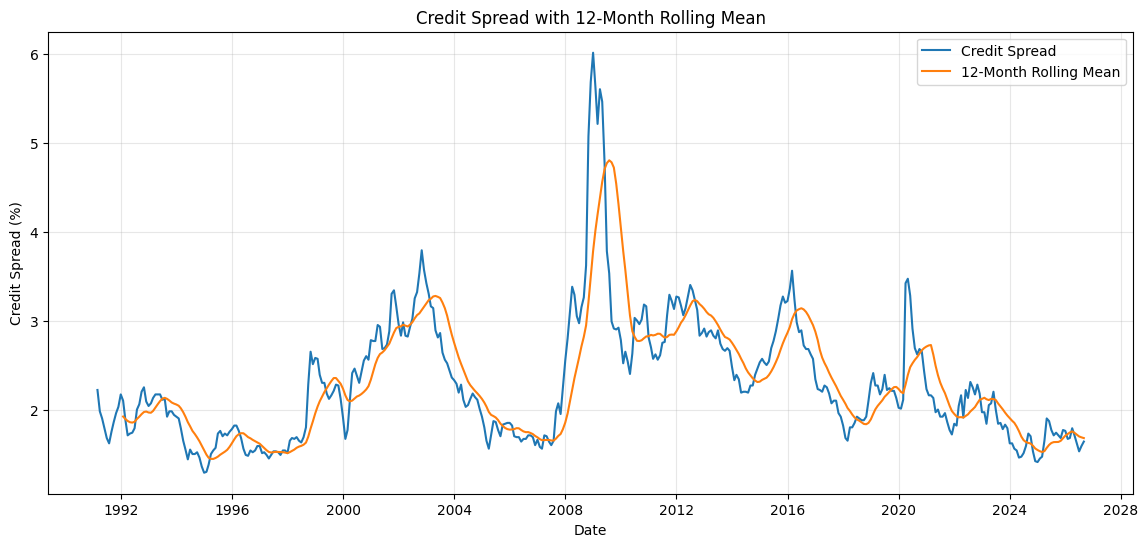

In [516]:
# Plotting the credit spread with 12-month rolling mean
rolling_mean = final_data["credit_spread"].rolling(window=12).mean()

plt.figure(figsize=(14, 6))

plt.plot(final_data["date"], final_data["credit_spread"], label="Credit Spread")
plt.plot(final_data["date"], rolling_mean, label="12-Month Rolling Mean")

plt.title("Credit Spread with 12-Month Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Credit Spread (%)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

The 12-month rolling mean smooths short-term fluctuations in credit spreads and highlights their broader underlying trend. The rolling mean rises during prolonged periods of financial stress, including the early-2000s downturn, the 2008–2009 financial crisis, and the COVID-19 shock, before gradually declining as credit conditions normalize. Because the measure incorporates the previous 12 months of observations, it responds more gradually than the monthly credit spread itself, making persistent periods of spread widening and tightening easier to identify.

#### **6.2.3 12-Month Rolling Standard Deviation**

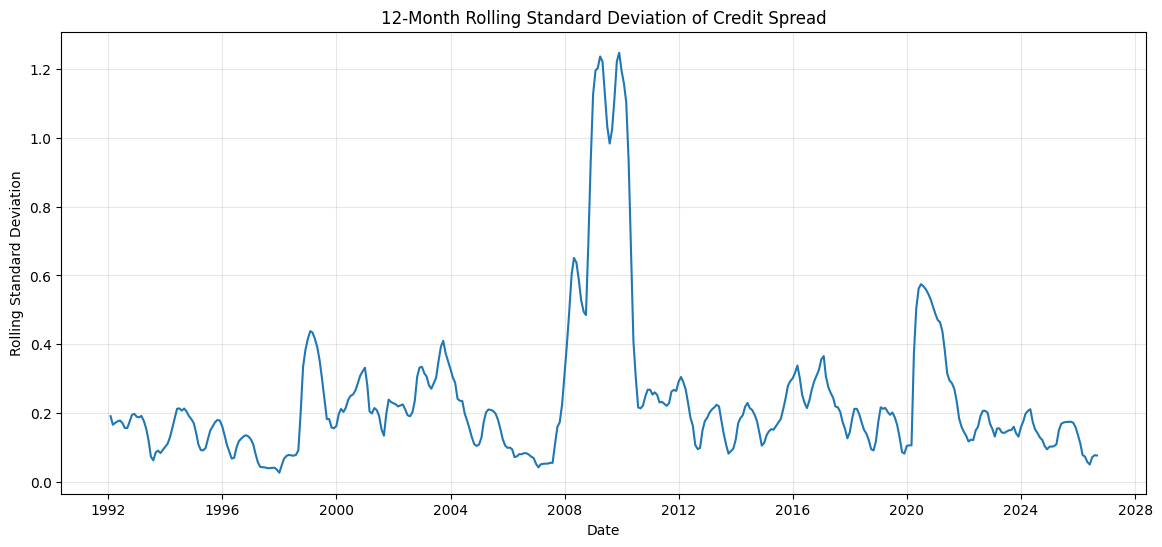

In [517]:
# Plot 12-month rolling standard deviation of the credit spread
rolling_std = final_data["credit_spread"].rolling(window=12).std()

plt.figure(figsize=(14, 6))

plt.plot(final_data["date"], rolling_std)

plt.title("12-Month Rolling Standard Deviation of Credit Spread")
plt.xlabel("Date")
plt.ylabel("Rolling Standard Deviation")
plt.grid(True, alpha=0.3)

plt.show()

The 12-month rolling standard deviation shows that credit spread variability increases considerably during periods of financial and economic stress. A notable increase appears around 1998–1999, a period associated with the Russian debt default and the collapse of Long-Term Capital Management (LTCM). The Russian default triggered a global flight to safer and more liquid assets, causing many credit and relative-value spreads to widen sharply. This was particularly damaging to highly leveraged convergence strategies used by LTCM, which were positioned for certain pricing differences to narrow rather than widen.

Elevated variability is also visible during the early 2000s following the dot-com downturn and the 2001 recession. The most pronounced and sustained increase occurs during the 2008–2009 Global Financial Crisis, when credit-market uncertainty and liquidity stress intensified substantially. Smaller but noticeable increases appear around 2015–2017 amid commodity-market and global growth concerns and following the 2020 COVID-19 shock. Overall, the pattern suggests that credit spread volatility rises substantially during periods of heightened economic uncertainty, changing risk perceptions, and financial-market stress.

#### **6.2.4 Augmented Dickey-Fuller Test**

The Augmented Dickey-Fuller (ADF) test is used to test whether the credit spread contains a unit root and is therefore non-stationary.

- **Null hypothesis (H₀):** The credit spread has a unit root and is non-stationary.
- **Alternative hypothesis (H₁):** The credit spread does not have a unit root and is stationary.

In [518]:
# Augmented Dickey-Fuller test for credit spread
adf_result = adfuller(final_data["credit_spread"].dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")

for key, value in adf_result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -3.7705663152724043
p-value: 0.003223231352117548
Critical Values:
   1%: -3.445830555854264
   5%: -2.8683646683004276
   10%: -2.570405316262976


The test produced an ADF statistic of −3.77 and a p-value of approximately 0.0032. Since the p-value is below the 1% significance level, the null hypothesis of a unit root is rejected. The ADF statistic is also more negative than the 1%, 5%, and 10% critical values, providing additional evidence against the presence of a unit root.

Therefore, **the credit spread is considered stationary** in the unit-root sense. This suggests that shocks to the level of the credit spread tend to dissipate over time rather than permanently shifting the series onto a new path. This behavior is consistent with the mean-reverting pattern observed in the time-series plot, where spreads widen sharply during periods of financial stress but eventually return toward more typical levels.

Although the ADF test provides evidence against a unit root, the rolling standard deviation indicates that the volatility of the credit spread is not constant over time and increases substantially during periods of market stress.

#### **6.2.5 ACF and PACF**

The ACF measures the overall linear relationship between the current observation and its lagged values, including both direct and indirect effects. The PACF measures the direct relationship between the current observation and a specific lag after controlling for the effects of the intermediate lags.

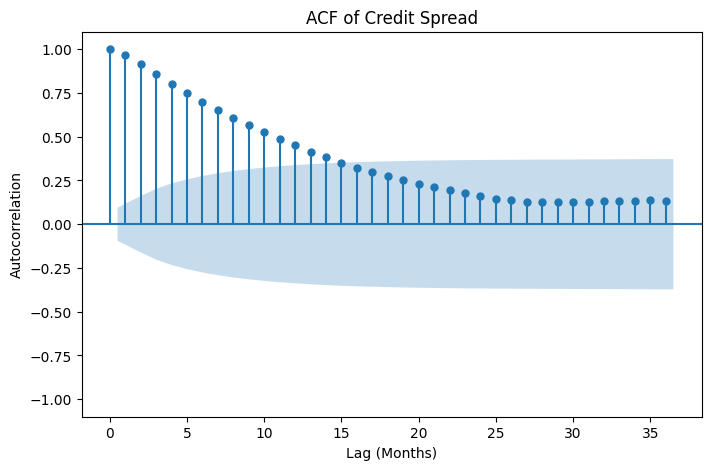

In [519]:
# Plot autocorrelation of the credit spread

fig, ax = plt.subplots(figsize=(8, 5))

plot_acf(
    final_data["credit_spread"].dropna(),
    lags=36,
    ax=ax
)

ax.set_title("ACF of Credit Spread")
ax.set_xlabel("Lag (Months)")
ax.set_ylabel("Autocorrelation")
ax.set_ylim(-1.1, 1.1)

plt.show()

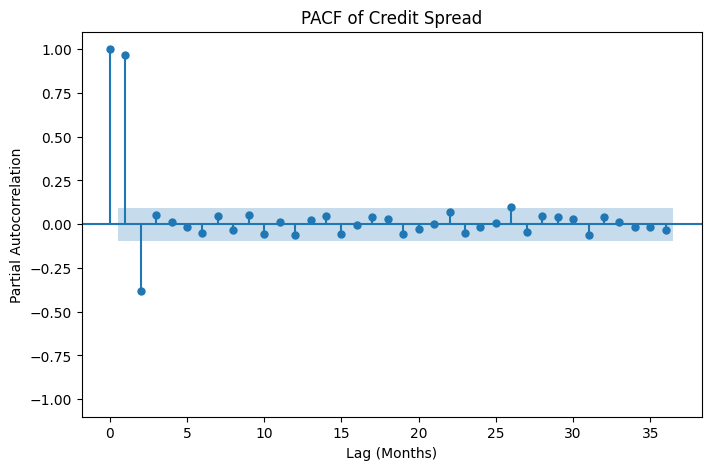

In [520]:
# Plot partial autocorrelation of the credit spread

fig, ax = plt.subplots(figsize=(8, 5))

plot_pacf(
    final_data["credit_spread"].dropna(),
    lags=36,
    method="ywm",
    ax=ax
)

ax.set_title("PACF of Credit Spread")
ax.set_xlabel("Lag (Months)")
ax.set_ylabel("Partial Autocorrelation")
ax.set_ylim(-1.1, 1.1)

plt.show()

The ACF shows strong positive autocorrelation across several lags, gradually declining as the lag increases. This indicates substantial persistence in credit spreads, with past spread levels remaining correlated with current levels over time.

The PACF isolates the direct effects of individual lags and shows a strong positive relationship at lag 1 and a substantial negative relationship at lag 2, while most subsequent lags are relatively small. This suggests that much of the direct temporal dependence is concentrated in the first few lags.

Overall, the ACF’s gradual decay and the concentration of the strongest PACF effects at early lags suggest that a relatively low-order autoregressive structure may capture much of the spread dynamics. These patterns support the inclusion of lagged credit spread values as predictors in the forecasting models explored later.

### **6.3 Correlation Analysis**

Correlation analysis is used to examine the strength and direction of the linear relationships between the credit spread and the macroeconomic and market variables, as well as relationships among the predictors themselves. This provides an initial indication of which variables may be associated with credit spread movements and helps identify potential multicollinearity among predictors.

In [521]:
# Correlation matrix

corr_matrix = final_data.drop(columns="date").corr()

corr_matrix

,credit_spread,credit_spread_6m_volatility,fed_funds_rate,yield_curve_10y3m,treasury_10y,vix,sp500_return,russell2000_return,inflation_yoy_initial,unemployment_rate_initial,indpro_growth,gdp_growth,wti_monthly_return
credit_spread,1.000000,0.642152,-0.579814,0.389020,-0.448662,0.649180,-0.115148,-0.058759,-0.316476,0.418726,-0.538710,-0.441045,-0.055904
credit_spread_6m_volatility,0.642152,1.000000,-0.278285,0.223290,-0.196308,0.636266,-0.061064,-0.049827,-0.257169,0.349873,-0.599516,-0.485523,-0.010247
fed_funds_rate,-0.579814,-0.278285,1.000000,-0.527981,0.794457,-0.140102,0.032930,-0.000936,0.291778,-0.492063,0.311626,0.288429,-0.024399
yield_curve_10y3m,0.389020,0.223290,-0.527981,1.000000,0.079217,0.089734,-0.075584,0.001298,-0.240756,0.636254,-0.081868,-0.209526,0.018703
treasury_10y,-0.448662,-0.196308,0.794457,0.079217,1.000000,-0.140132,-0.003715,0.012225,0.208582,-0.134308,0.312853,0.201573,-0.007330
vix,0.649180,0.636266,-0.140102,0.089734,-0.140132,1.000000,-0.250565,-0.241283,-0.004419,0.135583,-0.330838,-0.242893,-0.128326
sp500_return,-0.115148,-0.061064,0.032930,-0.075584,-0.003715,-0.250565,1.000000,0.821380,-0.122609,0.063688,0.027398,-0.041672,0.208285
russell2000_return,-0.058759,-0.049827,-0.000936,0.001298,0.012225,-0.241283,0.821380,1.000000,-0.112908,0.101317,-0.034580,-0.090987,0.254731
inflation_yoy_initial,-0.316476,-0.257169,0.291778,-0.240756,0.208582,-0.004419,-0.122609,-0.112908,1.000000,-0.344522,0.286808,0.309436,-0.110155
unemployment_rate_initial,0.418726,0.349873,-0.492063,0.636254,-0.134308,0.135583,0.063688,0.101317,-0.344522,1.000000,-0.232041,-0.445547,0.135839


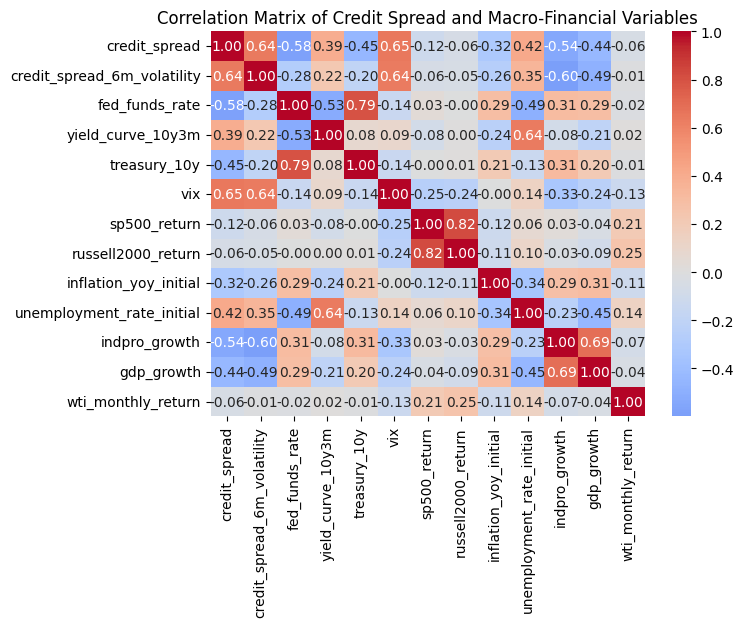

In [522]:
# Correlation heatmap

plt.figure(figsize=(7, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Credit Spread and Macro-Financial Variables")
plt.show()

The correlation analysis shows several notable relationships between credit spreads and the macro-financial variables. The VIX and six-month credit-spread volatility both have relatively strong positive correlations with credit spreads (0.65, 0.64), consistent with wider spreads occurring during periods of elevated financial-market stress and credit-market instability. Federal funds rate exhibits a relatively strong negative correlation with credit spreads (−0.58), followed by the industrial production (−0.54), real GDP growth (−0.44), and the 10-year Treasury yield (−0.45). The yield-curve slope and unemployment rate both show moderate positive correlations with credit spreads (0.39, 0.42), while contemporaneous S&P 500, Russell 2000, and WTI returns have relatively weak correlations with credit spreads.

Several predictors are also strongly correlated with one another, indicating potential overlap in the information they capture. S&P 500 and Russell 2000 returns have a correlation of 0.82, while the federal funds rate and 10-year Treasury yield have a correlation of 0.79. Industrial production and real GDP growth are positively correlated (0.69), reflecting their common relationship with the business cycle. Credit-spread volatility is also strongly related to the VIX (0.64), while the yield-curve slope and unemployment rate have a correlation of 0.62. These relationships suggest potential multicollinearity among some predictors and will be considered during model specification and evaluation.

### **6.4 Lagged Relationships**

The correlation analysis above examines contemporaneous relationships between credit spreads and the economic and financial predictors. However, changes in economic and market conditions may be associated with credit spreads over different time horizons. To explore these relationships, correlations between the current credit spread and past values of each predictor are examined at 1-, 3-, 6-, and 12-month lags, representing short-term, quarterly, semiannual, and annual horizons. The contemporaneous correlation (lag 0) is also included as a reference. This analysis helps identify how the strength of these relationships changes over time and which lag horizons may be useful for subsequent feature construction and forecasting.

In [523]:
# Lagged correlations between predictor variables and credit spread
predictors = [
    "fed_funds_rate",
    "yield_curve_10y3m",
    "treasury_10y",
    "vix",
    "sp500_return",
    "russell2000_return",
    "wti_monthly_return",
    "indpro_growth",
    "gdp_growth",
    "inflation_yoy_initial",
    "unemployment_rate_initial",
    "credit_spread_6m_volatility"
]

lags = [0, 1, 3, 6, 12]

lagged_corr = pd.DataFrame(index=predictors)

for lag in lags:
    lagged_corr[f"Lag {lag}"] = [
        final_data["credit_spread"].corr(final_data[var].shift(lag))
        for var in predictors
    ]

lagged_corr.round(2)

,Lag 0,Lag 1,Lag 3,Lag 6,Lag 12
fed_funds_rate,-0.58,-0.55,-0.50,-0.42,-0.24
yield_curve_10y3m,0.39,0.37,0.35,0.33,0.18
treasury_10y,-0.45,-0.44,-0.39,-0.32,-0.24
vix,0.65,0.66,0.57,0.45,0.29
sp500_return,-0.12,-0.22,-0.25,-0.22,-0.14
russell2000_return,-0.06,-0.16,-0.18,-0.15,-0.10
wti_monthly_return,-0.06,-0.11,-0.12,-0.05,-0.00
indpro_growth,-0.54,-0.50,-0.41,-0.30,-0.11
gdp_growth,-0.44,-0.40,-0.34,-0.24,-0.16
inflation_yoy_initial,-0.32,-0.27,-0.20,-0.13,-0.16


The lagged correlation analysis shows that the relationships between most predictors and credit spreads generally weaken as the lag horizon increases, suggesting that more recent economic and financial conditions have the strongest association with current spread levels. The VIX exhibits the strongest lagged relationship, with its correlation increasing slightly from 0.65 contemporaneously to 0.66 at a one-month lag, before gradually declining at longer horizons. Six-month credit spread volatility also exhibits a strong relationship, with a contemporaneous correlation of 0.64 that declines to 0.61 at a one-month lag and continues to weaken at longer horizons. Industrial production growth also maintains a relatively strong negative relationship at short lags, while GDP growth, the federal funds rate, the 10-year Treasury yield, the yield-curve slope, inflation, and unemployment generally show progressively weaker relationships as their observations become more distant.

Market-return variables exhibit a somewhat different pattern. The contemporaneous correlations of S&P 500, Russell 2000, and WTI returns with credit spreads are relatively weak, but their negative relationships strengthen at short lags. Both equity indices reach their strongest correlations at a three-month lag, approximately −0.26 for the S&P 500 and −0.18 for the Russell 2000. WTI returns similarly reach their strongest, although still weak, correlation of approximately −0.13 at three months. These patterns suggest that some recent market movements may contain information about subsequent credit-spread conditions that is not fully reflected in contemporaneous correlations.

### **6.5 EDA Summary**

The exploratory analysis reveals that credit spreads are highly persistent but mean-reverting, with pronounced widening and increased volatility during periods of financial and economic stress. The ACF and PACF confirm strong short-term dependence, supporting the use of lagged spread information in forecasting. Among the economic and financial predictors, the VIX and six-month credit-spread volatility show the strongest positive relationships with credit spreads, while industrial production growth, the federal funds rate, GDP growth, and the 10-year Treasury yield exhibit notable negative relationships. Most relationships weaken as the lag horizon increases, suggesting that more recent information is generally more relevant for credit-spread dynamics. However, equity-market and WTI returns show somewhat stronger relationships at short lags than contemporaneously, indicating that recent market movements may contain additional forecasting information. Overall, these findings provide the basis for the lagged feature construction and forecasting models developed in the following sections.

## **7. Lagged Feature Construction**

 Lagged features are introduced to capture persistence and delayed relationships between credit spreads and economic and financial conditions. The forecasting target is shifted one month ahead so that information available at the end of the current month is used to predict the credit spread in the following month. For each candidate predictor, 1-, 3-, 6-, and 12-month lags are created to examine whether recent or longer-term historical conditions contain useful forecasting information. These lagged variables are treated as candidate features rather than automatically included in the final model; their usefulness will ultimately be evaluated using out-of-sample forecasting performance.

### **7.1 Forecast Target**

In [524]:
# Create a separate dataset for modeling features
model_data = final_data.copy()

# One-month-ahead forecasting target:
# row t contains information available through month t,
# while the target is the credit spread in month t+1
model_data["credit_spread_target"] = model_data["credit_spread"].shift(-1)

model_data[
    ["date", "credit_spread", "credit_spread_target"]
].tail()

,date,credit_spread,credit_spread_target
422,2026-04-30,1.71,1.62
423,2026-05-31,1.62,1.53
424,2026-06-30,1.53,1.59
425,2026-07-31,1.59,1.64
426,2026-08-31,1.64,NaN


In [525]:
# Remove final row because next month's target is not yet observed
model_data = model_data.dropna(subset=["credit_spread_target"]).copy()

### **7.2 Predictor Lags**

In [526]:
# Variables for which lagged features will be constructed
lag_variables = [
    "credit_spread",
    "credit_spread_6m_volatility",
    "fed_funds_rate",
    "yield_curve_10y3m",
    "treasury_10y",
    "vix",
    "sp500_return",
    "russell2000_return",
    "wti_monthly_return",
    "indpro_growth",
    "gdp_growth",
    "inflation_yoy_initial",
    "unemployment_rate_initial"
]

# Candidate lag horizons identified during EDA
lags = [1, 3, 6, 12]

# Creating columns for each lagged feature in "model_data" dataset
for variable in lag_variables:
    for lag in lags:
        model_data[f"{variable}_lag{lag}"] = model_data[variable].shift(lag)

In [527]:
# Updated dataset check
model_data.head()

,date,credit_spread,credit_spread_6m_volatility,fed_funds_rate,yield_curve_10y3m,treasury_10y,vix,sp500_return,russell2000_return,inflation_yoy_initial,...,gdp_growth_lag6,gdp_growth_lag12,inflation_yoy_initial_lag1,inflation_yoy_initial_lag3,inflation_yoy_initial_lag6,inflation_yoy_initial_lag12,unemployment_rate_initial_lag1,unemployment_rate_initial_lag3,unemployment_rate_initial_lag6,unemployment_rate_initial_lag12
0,1991-02-28,2.22,0.233302,6.25,1.80,8.02,21.598421,6.728118,10.980094,5.559906,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1991-03-31,1.98,0.161204,6.12,2.13,8.05,17.744211,2.220283,6.881247,5.300078,...,NaN,NaN,5.559906,NaN,NaN,NaN,6.2,NaN,NaN,NaN
2,1991-04-30,1.90,0.191590,5.91,2.34,8.02,17.372727,0.031980,-0.233901,4.732351,...,NaN,NaN,5.300078,NaN,NaN,NaN,6.5,NaN,NaN,NaN
3,1991-05-31,1.79,0.242899,5.78,2.35,8.06,16.932273,3.860497,4.530799,4.802479,...,NaN,NaN,4.732351,5.559906,NaN,NaN,6.8,6.2,NaN,NaN
4,1991-06-30,1.68,0.258489,5.90,2.53,8.24,17.135000,-4.789263,-6.016595,4.949729,...,NaN,NaN,4.802479,5.300078,NaN,NaN,6.6,6.5,NaN,NaN


### **7.3 Feature-Target Correlations**

This analysis examines the correlation between each feature, including lagged variables, and the one-month-ahead credit spread target. Correlations are ranked by absolute magnitude from strongest to weakest, since both strong positive and strong negative relationships may provide useful predictive information. The original correlation signs are retained to indicate the direction of each relationship.

In [528]:
# Correlations of all variables with the one-month-ahead target
target_corr = (
    model_data.corr()["credit_spread_target"]
    .drop("credit_spread_target")
)

# Sort by absolute correlation strength while preserving the sign
target_corr = target_corr.loc[
    target_corr.abs().sort_values(ascending=False).index
].round(2)

pd.set_option("display.max_rows", None)
target_corr = target_corr.drop(index="date", errors="ignore")

target_corr

,credit_spread_target
credit_spread,0.97
credit_spread_lag1,0.92
credit_spread_lag3,0.81
vix,0.66
credit_spread_lag6,0.66
vix_lag1,0.62
credit_spread_6m_volatility,0.61
credit_spread_6m_volatility_lag1,0.58
fed_funds_rate,-0.55
vix_lag3,0.53


The feature-target correlations demonstrate strong persistence in credit spreads, with the current spread showing the strongest relationship with the one-month-ahead target (0.97), followed by the one-month and three-month spread lags (0.92 and 0.81). The VIX also exhibits a strong positive relationship with the next-month spread (0.66), while six-month credit-spread volatility shows a similarly strong association (0.61), with both variables retaining meaningful relationships at short lags. Among the macroeconomic and interest-rate predictors, the federal funds rate and industrial production growth exhibit relatively strong negative relationships with the target (−0.56 and −0.50), followed by GDP growth and the 10-year Treasury yield. The yield-curve slope and unemployment rate show moderate positive relationships.

Equity-market and WTI returns exhibit substantially weaker correlations with the one-month-ahead target, although some short lags show stronger relationships than their contemporaneous values. Overall, correlations generally decline as the lag horizon increases, indicating that more recent information tends to have a stronger relationship with near-term credit spreads. These correlations are descriptive and do not by themselves determine which predictors will improve out-of-sample forecasting performance.

## **8. Modeling and Forecast Evauation**

### **8.1 Modeling Strategy and Time-Based Split**

This project forecasts credit spreads one month ahead. Each forecast uses historical credit spreads and economic and financial information available through the current month to predict the credit spread for the following month. Since the data are time-series observations, they are kept in chronological order rather than randomly split. The earlier part of the dataset is used to train and develop the models, while the most recent years are reserved as an out-of-sample test period to evaluate performance on unseen data. An expanding historical window is used so that each new forecast can incorporate all information that would have been available up to that point.

Since the final dataset runs from 1991-02-28 to 2026-07-31, the split is going to be:

- Training/development: 1991-02-28 through 2021-12-31
- Out-of-sample test: 2022-01-31 through 2026-07-31

In [529]:
 #Defining the chronological train-test split

split_date = pd.Timestamp("2022-01-31")

model_sample = model_data.dropna(
    subset=["credit_spread_target"]
).copy()

train_data = model_sample[
    model_sample["date"] < split_date
].copy()

test_data = model_sample[
    model_sample["date"] >= split_date
].copy()

print(
    "Training period:",
    train_data["date"].min(),
    "to",
    train_data["date"].max()
)

print(
    "Test period:",
    test_data["date"].min(),
    "to",
    test_data["date"].max()
)

print("Training observations:", len(train_data))
print("Test observations:", len(test_data))

Training period: 1991-02-28 00:00:00 to 2021-12-31 00:00:00
Test period: 2022-01-31 00:00:00 to 2026-07-31 00:00:00
Training observations: 371
Test observations: 55


In [530]:
# Confirming that the training sample ends before the test sample begins

print("Last training date:", train_data["date"].max())
print("First test date:", test_data["date"].min())

Last training date: 2021-12-31 00:00:00
First test date: 2022-01-31 00:00:00


### **8.2 Forecasting Benchmarks**

Two simple benchmarks are used to evaluate whether more complex forecasting models provide meaningful improvements in one-month-ahead credit spread forecasts. The first is a naive persistence forecast, which assumes that next month’s spread will equal the current month’s spread. The second is an AR(1) model, which estimates the relationship between the current spread and the following month’s spread from the historical training data.

#### **8.2.1 Naive Baseline Forecast**

A naive forecast is used as a simple benchmark for comparing the forecasting models. It predicts that next month’s credit spread will be the same as the credit spread observed this month. Since credit spreads tend to be persistent and often change gradually from month to month, this simple approach can provide a useful benchmark. The performance of the other models can then be compared with the naive forecast to determine whether they produce more accurate predictions

In [531]:
# Creating a copy of the test data for baseline evaluation

baseline_test = test_data.copy()

# Creating the naive one-month-ahead forecast
baseline_test["naive_prediction"] = baseline_test["credit_spread"]

In [532]:
baseline_test[
    ["date", "credit_spread", "credit_spread_target", "naive_prediction"]
].head(10)

,date,credit_spread,credit_spread_target,naive_prediction
371,2022-01-31,1.82,2.04,1.82
372,2022-02-28,2.04,2.16,2.04
373,2022-03-31,2.16,1.91,2.16
374,2022-04-30,1.91,2.22,1.91
375,2022-05-31,2.22,2.13,2.22
376,2022-06-30,2.13,2.31,2.13
377,2022-07-31,2.31,2.25,2.31
378,2022-08-31,2.25,2.17,2.25
379,2022-09-30,2.17,2.28,2.17
380,2022-10-31,2.28,2.18,2.28


In [533]:
# Actual next-month credit spreads
y_actual = baseline_test["credit_spread_target"]

# Naive one-month-ahead predictions
y_naive = baseline_test["naive_prediction"]

# Evaluating the naive baseline
naive_mae = mean_absolute_error(y_actual, y_naive)
naive_rmse = np.sqrt(mean_squared_error(y_actual, y_naive))

print("Naive Baseline MAE:", round(naive_mae, 4))
print("Naive Baseline RMSE:", round(naive_rmse, 4))

Naive Baseline MAE: 0.0931
Naive Baseline RMSE: 0.1184


In [534]:
naive_r2 = r2_score(y_actual, y_naive)

print(f"Naive Out-of-Sample R²: {naive_r2:.4f}")

Naive Out-of-Sample R²: 0.7666


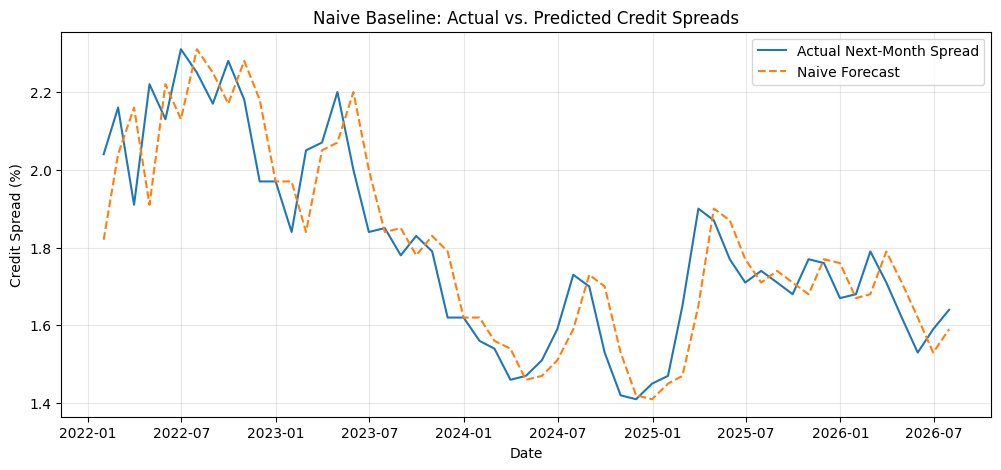

In [535]:
# Plotting actual vs. naive one-month-ahead forecasts

plt.figure(figsize=(12, 5))

plt.plot(
    baseline_test["date"],
    baseline_test["credit_spread_target"],
    label="Actual Next-Month Spread"
)

plt.plot(
    baseline_test["date"],
    baseline_test["naive_prediction"],
    label="Naive Forecast",
    linestyle="--"
)

plt.title("Naive Baseline: Actual vs. Predicted Credit Spreads")
plt.xlabel("Date")
plt.ylabel("Credit Spread (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

**Naive Baseline Interpretation:** The naive forecast produces a mean absolute error **(MAE) of 0.0931**, meaning that its one-month-ahead predictions differ from the actual credit spread by approximately **9 basis points on average**. The **RMSE is higher at 0.1184**, or approximately **12 basis points**, reflecting the greater penalty placed on larger forecast errors. These results establish a **baseline against which the more advanced forecasting models can be compared**.

#### **8.2.2 Autoregressive AR(1) Benchmark**

The AR(1) benchmark extends the naive persistence forecast by estimating the relationship between the current credit spread and the following month’s spread from the training data. Unlike the naive benchmark, which assumes a one-to-one relationship between consecutive months, the AR(1) model estimates the degree of persistence directly from historical observations. This provides a simple autoregressive benchmark against which more complex models can be evaluated.

In [536]:
# Define predictor and target
X_train_ar1 = train_data[["credit_spread"]]
y_train_ar1 = train_data["credit_spread_target"]

X_test_ar1 = test_data[["credit_spread"]]
y_test_ar1 = test_data["credit_spread_target"]

# Fit AR(1) model
ar1_model = LinearRegression()
ar1_model.fit(X_train_ar1, y_train_ar1)

# Generate one-month-ahead predictions
ar1_predictions = ar1_model.predict(X_test_ar1)

In [537]:
# Evaluate out-of-sample performance
ar1_mae = mean_absolute_error(y_test_ar1, ar1_predictions)
ar1_rmse = np.sqrt(mean_squared_error(y_test_ar1, ar1_predictions))

print("AR(1) MAE:", round(ar1_mae, 4))
print("AR(1) RMSE:", round(ar1_rmse, 4))

AR(1) MAE: 0.0948
AR(1) RMSE: 0.1185


In [538]:
from sklearn.metrics import r2_score

ar1_r2 = r2_score(y_test_ar1, ar1_predictions)

print(f"AR(1) Out-of-Sample R²: {ar1_r2:.4f}")

AR(1) Out-of-Sample R²: 0.7664


In [539]:
# Display estimated AR(1) parameters
print("Intercept:", round(ar1_model.intercept_, 4))
print("AR(1) coefficient:", round(ar1_model.coef_[0], 4))

Intercept: 0.0708
AR(1) coefficient: 0.9696


The AR(1) coefficient of 0.97 indicates strong persistence in credit spreads, meaning that the current spread is a strong predictor of the following month’s spread. The small positive intercept of 0.07 represents the constant component of the model.

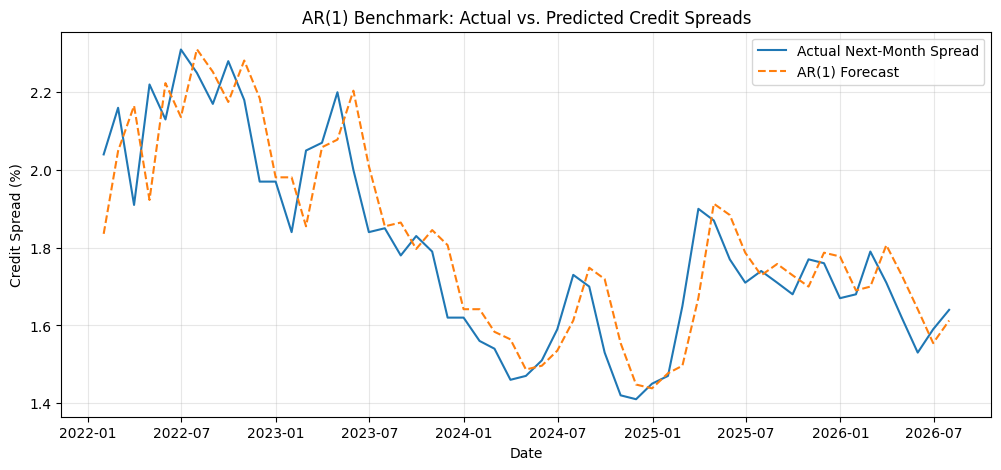

In [540]:
# Plotting actual vs. AR(1) predictions

plt.figure(figsize=(12, 5))

# Actual next-month credit spread
plt.plot(
    test_data["date"],
    y_test_ar1,
    label="Actual Next-Month Spread"
)

# AR(1) forecast
plt.plot(
    test_data["date"],
    ar1_predictions,
    label="AR(1) Forecast",
    linestyle="--"
)

plt.title("AR(1) Benchmark: Actual vs. Predicted Credit Spreads")
plt.xlabel("Date")
plt.ylabel("Credit Spread (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

**AR(1) Benchmark Interpretation:** The AR(1) model produced an **MAE of 0.0948** and **RMSE of 0.1185**, slightly underperforming the naive persistence benchmark (MAE 0.0931; RMSE 0.1184). The estimated AR(1) **coefficient of 0.9696** indicates very strong month-to-month persistence in credit spreads, consistent with the earlier autocorrelation analysis. However, estimating the autoregressive relationship did not improve out-of-sample accuracy relative to simply assuming that the current spread persists into the following month. Therefore, the naive persistence forecast remains the stronger benchmark for subsequent models.

### **8.3 Linear Regression Models**

This section evaluates a sequence of linear regression models for one-month-ahead credit spread forecasting. The specifications are expanded progressively to assess the contribution of economic and market predictors, current and lagged credit spreads, and lagged predictor information. Ridge regression is then used to examine whether L2 regularization improves performance when correlated predictors are included.

All estimated forecasting models are evaluated using an expanding-window approach, in which the model is re-estimated after each new observation becomes available and used to generate the subsequent one-month-ahead forecast.

#### **8.3.1 Baseline OLS - contemporaneus economic/market predictors**

Ordinary Least Squares (OLS) regression is used as the first multivariable forecasting model to evaluate whether current economic and market conditions contain information about the following month’s credit spread. The model uses the Federal Funds Rate, 10Y–3M yield curve slope, VIX, S&P 500 return, inflation, and unemployment rate available at the end of ***month t*** to predict the credit spread in ***month t+1***. Credit-spread lags are intentionally excluded from this initial specification so that the predictive contribution of external economic and market variables can be evaluated separately from the strong persistence observed in credit spreads. The model is evaluated out of sample against the naive persistence benchmark using MAE and RMSE.

In [541]:

features_ols = [
    "fed_funds_rate",
    "yield_curve_10y3m",
    "treasury_10y",
    "vix",
    "sp500_return",
    "russell2000_return",
    "wti_monthly_return",
    "inflation_yoy_initial",
    "unemployment_rate_initial",
    "indpro_growth",
    "gdp_growth",
]

target = "credit_spread_target"

In [542]:
# Expanding-window one-month-ahead forecasts
ols_predictions = []

for i in range(len(test_data)):

    # Expand training sample by adding previously observed test rows
    expanding_train = pd.concat(
        [train_data, test_data.iloc[:i]],
        axis=0
    )

    X_train_exp = expanding_train[features_ols]
    y_train_exp = expanding_train[target]

    X_test_i = test_data[features_ols].iloc[[i]]

    # Refit OLS using all information available up to that point
    ols_model = LinearRegression()
    ols_model.fit(X_train_exp, y_train_exp)

    # Forecast next month's spread
    prediction = ols_model.predict(X_test_i)[0]
    ols_predictions.append(prediction)

# Actual test targets
y_test = test_data[target]

# Out-of-sample performance
ols_mae = mean_absolute_error(y_test, ols_predictions)
ols_rmse = np.sqrt(mean_squared_error(y_test, ols_predictions))
ols_r2 = r2_score(y_test, ols_predictions)

print("Expanding-Window OLS - Economic/Market Predictors Only")
print("MAE:", round(ols_mae, 4))
print("RMSE:", round(ols_rmse, 4))
print("R²:", round(ols_r2, 4))

Expanding-Window OLS - Economic/Market Predictors Only
MAE: 0.3005
RMSE: 0.3588
R²: -1.1418


**Baseline OLS Performance:** Using an expanding-window forecasting approach, the OLS model with contemporaneous economic and market predictors produces an MAE of 0.3005 and RMSE of 0.3588, substantially higher than the naive persistence benchmark. The negative out-of-sample R² of -1.1418 further indicates weak predictive performance. These results suggest that contemporaneous macroeconomic and market conditions alone are insufficient to capture the strong persistence in credit spreads, motivating the inclusion of current spread dynamics, volatility, and lagged predictors in subsequent models.

#### **8.3.2 OLS with Credit Spread and Economic/Market Predictors**

Given where the credit spread is today, do current economic and market conditions help predict where it will be next month?

In [543]:
features_ols_spread = [
    "credit_spread",
    "credit_spread_6m_volatility",
    "fed_funds_rate",
    "yield_curve_10y3m",
    "treasury_10y",
    "vix",
    "sp500_return",
    "russell2000_return",
    "wti_monthly_return",
    "inflation_yoy_initial",
    "unemployment_rate_initial",
    "indpro_growth",
    "gdp_growth"
]

target = "credit_spread_target"

In [544]:
ols_spread_predictions = []

for i in range(len(test_data)):

    # Expanding training dataset
    expanding_train = pd.concat(
        [train_data, test_data.iloc[:i]]
    )

    # Separate predictors and target
    X_train = expanding_train[features_ols_spread]
    y_train = expanding_train[target]

    # Current test observation
    X_test = test_data[features_ols_spread].iloc[[i]]

    # Fit model
    ols_spread_model = LinearRegression()
    ols_spread_model.fit(X_train, y_train)

    # Predict one month ahead
    prediction = ols_spread_model.predict(X_test)[0]
    ols_spread_predictions.append(prediction)

# Actual target values for evaluation
y_test = test_data[target]

In [545]:
# Evaluating expanding-window OLS performance
ols_spread_mae = mean_absolute_error(y_test, ols_spread_predictions)

ols_spread_rmse = np.sqrt(
    mean_squared_error(y_test, ols_spread_predictions)
)

ols_spread_r2 = r2_score(y_test, ols_spread_predictions)

print("Expanding-Window OLS - Spread + Volatility + Economic/Market Predictors")
print("MAE:", round(ols_spread_mae, 4))
print("RMSE:", round(ols_spread_rmse, 4))
print("R²:", round(ols_spread_r2, 4))

Expanding-Window OLS - Spread + Volatility + Economic/Market Predictors
MAE: 0.0854
RMSE: 0.1057
R²: 0.814


**OLS with Credit Spread, Rolling Volatility and Economic/Market Predictors:** Adding the current credit spread and its six-month rolling volatility to the economic and market predictors, while using expanding window approach,  improved out-of-sample forecasting performance. The model achieved an MAE of 0.0854, RMSE of 0.1057, and R² of 0.814, outperforming both the naive persistence benchmark (MAE = 0.0931, RMSE = 0.1184, R² = 0.7666) and the AR(1) benchmark (MAE = 0.0948, RMSE = 0.1185, R² = 0.7664). These results suggest that current macro-financial conditions and recent credit-spread volatility provide additional predictive information beyond the strong persistence in credit spreads.

#### **Multicollinearity Diagnostic**

A standard way to examine multicollinearity is through Variance Inflation Factor (VIF)

In [546]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Predictors used in the current OLS model
X_vif = train_data[features_ols_spread].dropna()

vif = pd.DataFrame()
vif["Feature"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif.sort_values("VIF", ascending=False)

,Feature,VIF
4,treasury_10y,390.932162
2,fed_funds_rate,203.717087
3,yield_curve_10y3m,88.711640
0,credit_spread,31.188104
5,vix,22.561810
10,unemployment_rate_initial,18.769976
9,inflation_yoy_initial,6.334007
1,credit_spread_6m_volatility,5.201750
12,gdp_growth,5.109539
11,indpro_growth,3.461625


In [547]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

# Excluding 10Y Treasury due to redundancy with other interest-rate predictors
features_vif = [
    feature for feature in features_ols_spread
    if feature != "treasury_10y"
]

X_vif = train_data[features_vif].dropna()

# Adding intercept to match the OLS specification
X_vif_const = add_constant(X_vif)

# Calculating VIF
vif = pd.DataFrame()
vif["Feature"] = X_vif_const.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif_const.values, i)
    for i in range(X_vif_const.shape[1])
]

# Excluding intercept from displayed results
vif = vif[vif["Feature"] != "const"]

vif.sort_values("VIF", ascending=False)

,Feature,VIF
1,credit_spread,4.055930
7,russell2000_return,3.266609
6,sp500_return,3.181747
5,vix,3.106824
11,indpro_growth,3.024121
2,credit_spread_6m_volatility,2.697208
12,gdp_growth,2.417372
3,fed_funds_rate,2.248685
10,unemployment_rate_initial,2.099216
4,yield_curve_10y3m,1.723882


The VIF analysis indicates substantial multicollinearity among several interest-rate predictors, particularly the standalone 10-year Treasury yield. As a robustness check, the 10-year Treasury yield was removed and the model was re-estimated. However, its removal substantially worsened out-of-sample forecasting performance, with MAE increasing from 0.0854 to 0.1132 and RMSE increasing from 0.1057 to 0.1482 and reducing R squared to 0.6346. Because the primary objective of the model is forecasting rather than coefficient interpretation, the 10-year Treasury yield is retained in the final specification despite its high VIF.

#### **8.3.3. OLS with Selected Current and Lagged Credit Spread and Economic/Market Predictors**

Does combining current and lagged credit-spread information with selected current and lagged macro-financial predictors improve the forecast of next month’s credit spread?

In [548]:
features_ols_lagged = [

    # Credit-spread dynamics
    "credit_spread",
    "credit_spread_lag1",
    "credit_spread_6m_volatility",

    # Market risk
    "vix",


    # Monetary policy
    "fed_funds_rate",

    # Interest-rate conditions
    "treasury_10y",
    "treasury_10y_lag1",
    "yield_curve_10y3m",


     # Equity market
    "sp500_return",
    "sp500_return_lag3",


    # Small-cap equity
    "russell2000_return_lag1",
    "russell2000_return_lag3",

    # Macroeconomic conditions
    "inflation_yoy_initial",
    "unemployment_rate_initial",
    "indpro_growth",
    "gdp_growth",

    # Energy market
    "wti_monthly_return_lag3"
]

target = "credit_spread_target"

In [549]:
# Expanding-window OLS with current and lagged predictors
ols_lagged_predictions = []

for i in range(len(test_data)):

    # Expand training data with previously observed test rows
    expanding_train = pd.concat(
        [train_data, test_data.iloc[:i]]
    )

    # Keep only rows with complete predictors and target
    expanding_train = expanding_train.dropna(
        subset=features_ols_lagged + [target]
    )

    # Separate predictors and target
    X_train = expanding_train[features_ols_lagged]
    y_train = expanding_train[target]

    # Current test observation
    X_test = test_data[features_ols_lagged].iloc[[i]]

    # Fit OLS
    ols_lagged_model = LinearRegression()
    ols_lagged_model.fit(X_train, y_train)

    # Predict one month ahead
    prediction = ols_lagged_model.predict(X_test)[0]
    ols_lagged_predictions.append(prediction)

# Actual test targets
y_test = test_data[target]

In [550]:
# Evaluating expanding-window lagged OLS
ols_lagged_mae = mean_absolute_error(
    y_test, ols_lagged_predictions
)

ols_lagged_rmse = np.sqrt(
    mean_squared_error(y_test, ols_lagged_predictions)
)

ols_lagged_r2 = r2_score(
    y_test, ols_lagged_predictions
)

print("Expanding-Window OLS - Current and Lagged Predictors")
print("MAE:", round(ols_lagged_mae, 4))
print("RMSE:", round(ols_lagged_rmse, 4))
print("R²:", round(ols_lagged_r2, 4))

Expanding-Window OLS - Current and Lagged Predictors
MAE: 0.0768
RMSE: 0.0993
R²: 0.8359


In [551]:
# Comparing out-of-sample model performance

print("Naive Persistence")
print("MAE:", round(naive_mae, 4))
print("RMSE:", round(naive_rmse, 4))
print("R²:", round(naive_r2, 4))

print("\nAR(1) Autoregressive Benchmark")
print("MAE:", round(ar1_mae, 4))
print("RMSE:", round(ar1_rmse, 4))
print("R²:", round(ar1_r2, 4))

print("\nOLS - Spread + Volatility + Economic/Market Predictors")
print("MAE:", round(ols_spread_mae, 4))
print("RMSE:", round(ols_spread_rmse, 4))
print("R²:", round(ols_spread_r2, 4))

print("\nExpanding-Window OLS - Current and Lagged Predictors")
print("MAE:", round(ols_lagged_mae, 4))
print("RMSE:", round(ols_lagged_rmse, 4))
print("R²:", round(ols_lagged_r2, 4))

Naive Persistence
MAE: 0.0931
RMSE: 0.1184
R²: 0.7666

AR(1) Autoregressive Benchmark
MAE: 0.0948
RMSE: 0.1185
R²: 0.7664

OLS - Spread + Volatility + Economic/Market Predictors
MAE: 0.0854
RMSE: 0.1057
R²: 0.814

Expanding-Window OLS - Current and Lagged Predictors
MAE: 0.0768
RMSE: 0.0993
R²: 0.8359


**OLS with Selected Current and Lagged Credit Spread and Macro-Financial Predictors:**  
The expanding-window OLS model with selected current and lagged predictors achieves the strongest overall out-of-sample forecasting performance, with an **MAE of 0.0768, RMSE of 0.0993, and R² of 0.8359**. Relative to the naive persistence benchmark, the model reduces MAE by approximately **17.5%** and RMSE by approximately **16.1%**, while increasing R² from **0.7666 to 0.8359**. The model also outperforms the AR(1) benchmark and the OLS specification using the current credit spread, rolling volatility, and contemporaneous economic and market predictors. These results suggest that selectively incorporating recent credit-spread dynamics and lagged macro-financial information provides additional predictive value for one-month-ahead credit-spread forecasting.

## **9. Directional Forecast Evaluation**



MAE and RMSE measure the magnitude of forecast errors but do not indicate whether a model correctly anticipates whether credit spreads will **widen or tighten**. Directional performance is therefore evaluated separately for the **AR(1) benchmark** and the **final expanding-window OLS model**.

This section evaluates directional performance in two steps. First, **directional accuracy** measures the proportion of months in which each model correctly predicts the direction of the subsequent credit-spread movement. Second, the **Pesaran–Timmermann test** evaluates whether the directional predictive ability of the final OLS model is statistically significant.

**Research question:** How accurately does the final expanding-window OLS model predict the direction of month-to-month credit-spread movements, how does its performance compare with the AR(1) benchmark, and is its directional predictive ability statistically significant?

### **9.1 Directional Accuracy**

### Direction Definition

The actual monthly change in the credit spread is calculated as:

$$
\text{Actual Change}_t = \text{Spread}_t - \text{Spread}_{t-1}
$$

The predicted monthly change is calculated as:

$$
\text{Predicted Change}_t = \widehat{\text{Spread}}_t - \text{Spread}_{t-1}
$$

A positive change represents **spread widening**, while a negative change represents **spread tightening**.

Directional accuracy is calculated as:

$$
\text{Directional Accuracy} =
\frac{\text{Number of Correct Direction Predictions}}
{\text{Total Number of Forecasts}}
\times 100
$$

### **AR(1) Benchmark**

First, we evaluate the directional accuracy of the AR(1) benchmark.

In [552]:
# AR(1) directional accuracy

# Credit spread, known when each forecast is made:
current_spread = X_test_ar1["credit_spread"].values

# Actual next-month spread:
actual_next_spread = y_test_ar1.values

# AR(1) Predicted next-month spread:
predicted_spread = np.array(ar1_predictions)

actual_change = actual_next_spread - current_spread
ar1_predicted_change = predicted_spread - current_spread

# Convert to directions:
ar1_actual_direction = np.sign(actual_change)
ar1_predicted_direction = np.sign(ar1_predicted_change)

# Calculate directional accuracy:
ar1_correct_directions = 0
for actual, predicted in zip(ar1_actual_direction, ar1_predicted_direction):
    if actual == predicted:
        ar1_correct_directions += 1

total_predictions = len(ar1_actual_direction)
ar1_directional_accuracy = (ar1_correct_directions / total_predictions)*100

print("Correct directions:", ar1_correct_directions)
print("Total predictions:", total_predictions)
print("AR(1) Directional Accuracy:", round(ar1_directional_accuracy, 2),"%")




Correct directions: 24
Total predictions: 55
AR(1) Directional Accuracy: 43.64 %


In [553]:
# Actual directions
actual_widening = np.sum(ar1_actual_direction == 1)
actual_tightening = np.sum(ar1_actual_direction == -1)

# Predicted directions
predicted_widening = np.sum(ar1_predicted_direction == 1)
predicted_tightening = np.sum(ar1_predicted_direction == -1)

print("Actual widening:", actual_widening)
print("Actual tightening:", actual_tightening)

print("Predicted widening:", predicted_widening)
print("Predicted tightening:", predicted_tightening)

print("Actual unchanged:", np.sum(ar1_actual_direction == 0))
print("Predicted unchanged:", np.sum(ar1_predicted_direction == 0))

Actual widening: 24
Actual tightening: 29
Predicted widening: 55
Predicted tightening: 0
Actual unchanged: 2
Predicted unchanged: 0


The AR(1) benchmark achieved a directional accuracy of 43.64%, correctly predicting 24 of 55 test observations. However, the model predicted spread widening in all 55 observations and never predicted tightening. Therefore, its 24 correct predictions correspond entirely to the 24 months in which spreads actually widened, indicating that **the benchmark did not discriminate between widening and tightening movements**.

### **OLS with Selected Current and Lagged Credit Spread and Economic/Market Predictors**

Next, we evaluate the directional accuracy of the final expanding-window OLS model and compare its ability to anticipate widening and tightening with the AR(1) benchmark.

In [554]:
# OLS lagged directional accuracy

# Credit spread known when each forecast is made
current_spread = test_data["credit_spread"].values

# Actual next-month spread
actual_next_spread = test_data[target].values

# OLS predicted next-month spread
predicted_spread = np.array(ols_lagged_predictions)

# Calculate actual and predicted changes
actual_change = actual_next_spread - current_spread
ols_predicted_change = predicted_spread - current_spread

# Convert to directions
ols_actual_direction = np.sign(actual_change)
ols_predicted_direction = np.sign(ols_predicted_change)

# Calculate directional accuracy
ols_correct_directions = 0

for actual, predicted in zip(ols_actual_direction, ols_predicted_direction):
    if actual == predicted:
        ols_correct_directions += 1

print("Correct directions:", ols_correct_directions)


# Calculate percentage
total_predictions = len(ols_actual_direction)
print("Total predictions:", total_predictions)

ols_directional_accuracy = (
    ols_correct_directions / total_predictions
) * 100

print(
    "OLS Directional Accuracy:",
    round(ols_directional_accuracy, 2),
    "%"
)

Correct directions: 36
Total predictions: 55
OLS Directional Accuracy: 65.45 %


In [555]:
actual_widening = np.sum(ols_actual_direction == 1)
actual_tightening = np.sum(ols_actual_direction == -1)

predicted_widening = np.sum(ols_predicted_direction == 1)
predicted_tightening = np.sum(ols_predicted_direction == -1)

print("Actual widening:", actual_widening)
print("Actual tightening:", actual_tightening)

print("Predicted widening:", predicted_widening)
print("Predicted tightening:", predicted_tightening)

print("Actual unchanged:", np.sum(ols_actual_direction == 0))
print("Predicted unchanged:", np.sum(ols_predicted_direction == 0))

Actual widening: 24
Actual tightening: 29
Predicted widening: 26
Predicted tightening: 29
Actual unchanged: 2
Predicted unchanged: 0


The OLS model with selected current and lagged predictors achieved a directional accuracy of 65.45%, correctly predicting 36 out of 55 monthly spread movements. Unlike the AR(1) benchmark, which predicted widening in every test observation, the OLS model predicted both widening and tightening, indicating a stronger ability to distinguish the direction of credit-spread movements.This represents 21.81-percentage-point improvement over the AR(1) benchmark’s 43.64% directional accuracy.

### **9.2 Statistical Significance of Directional Forecasts: Pesaran–Timmermann Test**

The final expanding-window OLS model achieved a directional accuracy of **65.45%**, correctly predicting the direction of credit spread movements in **36 out of 55 test observations**. However, directional accuracy alone does not establish whether this predictive performance is statistically meaningful. A model may achieve an apparently high hit rate partly because widening and tightening do not occur with equal frequency, or because the model itself tends to predict one direction more frequently than the other.

This issue is illustrated by the **AR(1) benchmark**, which achieved a directional accuracy of **43.64% (24 out of 55 months)** but predicted spread widening in every test observation. Its correct directional forecasts therefore correspond entirely to months in which spreads actually widened, indicating that the AR(1) model provides no meaningful discrimination between widening and tightening. For this reason, the Pesaran–Timmermann test is not applied to the AR(1) directional forecasts.

To evaluate whether the **final expanding-window OLS model** contains genuine directional forecasting information, the **Pesaran–Timmermann (PT) test** is applied. The test examines whether the predicted direction of credit spread changes is statistically associated with the actual direction of subsequent spread movements. It accounts for the frequencies with which widening and tightening occur in both the actual observations and the model predictions.

#### Hypotheses

The null and alternative hypotheses are:

$$
H_0: \text{Predicted and actual spread directions are independent}
$$

$$
H_1: \text{Predicted and actual spread directions are associated}
$$

Under the null hypothesis, any agreement between predicted and actual directions is attributable to the underlying frequencies of widening and tightening rather than genuine directional forecasting ability.

A significance level of **5%** is used:

- If **p < 0.05**, the null hypothesis is rejected, providing evidence that the model has statistically significant directional predictive ability.
- If **p ≥ 0.05**, the null hypothesis cannot be rejected, meaning there is insufficient evidence to conclude that the model has statistically significant directional predictive ability.

The Pesaran–Timmermann test is therefore applied to the **final expanding-window OLS model** to determine whether its observed directional accuracy reflects statistically significant information about future credit spread movements.

In [556]:
# Select observations where the spread either widened or tightened
nonzero_direction = (ols_actual_direction != 0) & (ols_predicted_direction != 0)

# Keep only those observations
actual_direction_for_test = ols_actual_direction[nonzero_direction]
predicted_direction_for_test = ols_predicted_direction[nonzero_direction]

print("Number of observations:", len(actual_direction_for_test))

Number of observations: 53


In [557]:
# Convert directions to binary values
actual_binary = (actual_direction_for_test == 1).astype(int)
predicted_binary = (predicted_direction_for_test == 1).astype(int)

# Create DataFrame to compare actual and predicted directions
direction_df = pd.DataFrame({
    "Actual Direction": actual_binary,
    "Predicted Direction": predicted_binary
})

direction_df.head()

,Actual Direction,Predicted Direction
0,1,1
1,1,1
2,0,0
3,1,1
4,0,1


In [558]:
direction_df["Correct"] = (
    direction_df["Actual Direction"] == direction_df["Predicted Direction"]
)

direction_df.head()

,Actual Direction,Predicted Direction,Correct
0,1,1,True
1,1,1,True
2,0,0,True
3,1,1,True
4,0,1,False


In [559]:
# Proportion of actual and predicted positive directions
p_actual = np.mean(actual_binary)
p_predicted = np.mean(predicted_binary)

# Expected directional accuracy under independence
p_star = (
    p_actual * p_predicted
    + (1 - p_actual) * (1 - p_predicted)
)

print("Actual positive proportion:", round(p_actual, 4))
print("Predicted positive proportion:", round(p_predicted, 4))
print("Expected accuracy under H0:", round(p_star, 4))

Actual positive proportion: 0.4528
Predicted positive proportion: 0.4717
Expected accuracy under H0: 0.5027


In [560]:
# Variance of observed directional accuracy
var_p = p_star * (1 - p_star) / n

# Variance adjustment for actual and predicted direction frequencies
var_p_star = (
    ((2 * p_actual - 1) ** 2) * p_predicted * (1 - p_predicted) / n
    +
    ((2 * p_predicted - 1) ** 2) * p_actual * (1 - p_actual) / n
)

# Adjusted variance
pt_variance = var_p - var_p_star

In [561]:
# Pesaran-Timmermann test statistic
pt_stat = (p_hat - p_star) / np.sqrt(pt_variance)

print("PT statistic:", round(pt_stat, 4))

PT statistic: 2.9166


In [562]:
from scipy.stats import norm

# Two-sided p-value
p_value = 2 * (1 - norm.cdf(abs(pt_stat)))

print("p-value:", round(p_value, 4))

p-value: 0.0035


#### **Pesaran–Timmermann Test Results**

The Pesaran–Timmermann test produced a **PT statistic of 2.92** and a **p-value of 0.0035**. Since the p-value is below the **1% significance level**, the null hypothesis that the predicted and actual spread directions are independent is rejected.

The results therefore provide evidence that the **final expanding-window OLS model has statistically significant directional predictive ability over the out-of-sample test period at the 1% significance level**. In other words, the model's ability to predict whether credit spreads widen or tighten is unlikely to be explained solely by the underlying frequencies of the two directions.


## **10. Statistical Comparison of Forecast Accuracy: Diebold–Mariano Test**

Although MAE and RMSE allow forecast errors to be compared numerically, a lower error does not necessarily mean that one model is statistically more accurate than another. The observed difference could partly reflect sampling variation during the test period.

The **Diebold–Mariano (DM) test** is therefore used to determine whether the forecast accuracy of the **final expanding-window OLS model** differs significantly from the **naive persistence benchmark**. The naive model is used because it provides the strongest benchmark based on the out-of-sample MAE and RMSE results.

The DM test compares the forecast losses of the two models for each observation in the test period. In this analysis, **squared forecast errors** are used as the loss function, consistent with the RMSE criterion used in the model evaluation.

### Hypotheses

The null and alternative hypotheses are:

$$
H_0: \text{The OLS and naive models have equal predictive accuracy}
$$

$$
H_1: \text{The OLS and naive models have different predictive accuracy}
$$

A significance level of **5%** is used:

- If **p < 0.05**, reject $H_0$: there is a statistically significant difference in forecast accuracy.
- If **p ≥ 0.05**, fail to reject $H_0$: there is insufficient evidence of a statistically significant difference in forecast accuracy.

In [563]:
# Actual next-month credit spread
actual_spread = test_data[target].values

# Final expanding-window OLS predictions
ols_predictions = np.array(ols_lagged_predictions)

# Naive persistence predictions:
# next month's spread is predicted to equal the current month's spread
naive_predictions = test_data["credit_spread"].values

print("Number of observations:", len(actual_spread))

Number of observations: 55


In [564]:
# Forecast errors
ols_error = actual_spread - ols_predictions
naive_error = actual_spread - naive_predictions

In [565]:
# Squared forecast errors
ols_loss = ols_error ** 2
naive_loss = naive_error ** 2

In [566]:
# Difference in forecast loss for each month
loss_difference = ols_loss - naive_loss

In [567]:
# Average difference in squared forecast errors
mean_loss_difference = np.mean(loss_difference)

print("Average loss difference:", round(mean_loss_difference, 6))

Average loss difference: -0.004163


In [568]:
# Number of forecast observations
n = len(loss_difference)

# Variance of the loss differences
loss_variance = np.var(loss_difference, ddof=1)

# Standard error of the average loss difference
standard_error = np.sqrt(loss_variance / n)

In [569]:
# Diebold-Mariano test statistic
dm_stat = mean_loss_difference / standard_error

print("DM statistic:", round(dm_stat, 4))

DM statistic: -1.8142


In [570]:
from scipy.stats import norm

# Two-sided p-value
dm_p_value = 2 * (1 - norm.cdf(abs(dm_stat)))

print("p-value:", round(dm_p_value, 4))

p-value: 0.0697


The Diebold–Mariano test produced a **DM statistic of -1.8142** and a **p-value of 0.0697**. Because the loss differential was defined as the squared forecast error of the final OLS model minus that of the naive persistence benchmark, the negative DM statistic indicates that the final expanding-window OLS model had lower squared forecast loss on average.

The p-value remains above the conventional **5% significance level**, so the null hypothesis of equal predictive accuracy cannot be rejected at the 5% level. However, the result is **statistically significant at the 10% level**, providing moderate evidence that the final OLS model improves predictive accuracy relative to the naive persistence benchmark.

The relatively small out-of-sample test size of **55 observations** may limit the statistical power of the test. Nevertheless, the combination of lower out-of-sample forecast errors and the Diebold–Mariano result provides evidence that the final OLS specification offers improved one-month-ahead credit-spread forecasting performance relative to the naive persistence benchmark.

## **11. Conclusion**

This project examined whether macroeconomic and financial indicators can improve one-month-ahead forecasts of corporate credit spreads beyond simple persistence and autoregressive benchmarks. Several model specifications were evaluated, with the final expanding-window OLS model incorporating selected current and lagged credit-spread and macro-financial predictors providing the strongest overall out-of-sample performance.

The final OLS model achieved an **MAE of 0.0768, RMSE of 0.0993, and R² of 0.8359**, outperforming both the naive persistence and AR(1) benchmarks on these point-forecast metrics. Relative to naive persistence, this represents reductions of approximately **17.5% in MAE and 16.1% in RMSE**. The model also achieved a **directional accuracy of 65.45% (36 out of 55 months)**, compared with **43.64% for the AR(1) benchmark**.

The Pesaran–Timmermann test provided evidence that the final OLS model's directional predictive ability is statistically significant at the **1% level (p = 0.0035)**. This provides strong evidence that the model's ability to anticipate credit-spread widening and tightening is not explained solely by the underlying frequencies of the two directions.

The Diebold–Mariano test produced a **p-value of 0.0697** when comparing squared forecast loss with the naive persistence benchmark. Although the null hypothesis of equal predictive accuracy cannot be rejected at the conventional **5% significance level**, it can be rejected at the **10% level**, providing moderate statistical evidence of improved predictive accuracy. The relatively small out-of-sample test period of **55 observations** should nevertheless be considered when interpreting the statistical results.

Overall, the results suggest that incorporating selected macro-financial information and recent credit-spread dynamics provides useful incremental information for one-month-ahead credit-spread forecasting. The final model improves both point-forecast performance and directional accuracy relative to the benchmarks, with particularly strong statistical evidence for its ability to anticipate the direction of future credit-spread movements and moderate statistical evidence for improved point-forecast accuracy.

## **12. Limitations and Future Work**

Several limitations provide opportunities for extending this analysis.

**Data availability and alignment** represented one of the main constraints of the project. Potentially useful macroeconomic and financial predictors were available over different historical periods, frequencies, and release schedules. Because the analysis was designed to preserve the information that would realistically have been available at each forecast date, some additional variables could not be incorporated without substantially shortening the sample or creating potential look-ahead bias. Future work could expand the predictor set by obtaining longer and consistently release-aware histories for additional macroeconomic, market, credit, liquidity, and expectations-based indicators.

A second limitation is the relatively** small out-of-sample test period of 55 monthly observations**. While this period provides a meaningful recent forecasting exercise, the limited number of observations reduces the statistical power of forecast-comparison tests and increases uncertainty around estimated performance differences between competing models. Future research could evaluate the model over a longer out-of-sample period and across multiple economic and credit-market regimes.

Finally, several model specifications and feature combinations were explored during model development. A more rigorous extension could use **separate training, validation, and final holdout periods**, allowing feature and model selection to be performed on the validation sample while preserving a completely untouched test period for final evaluation.

Future work could therefore focus on building a richer and longer release-aware dataset, expanding the set of economically motivated predictors, and evaluating the forecasting framework over a larger independent test sample.